![CO2 Emissions](co2.jpg)

# 1.Understanding the Task

- Import the dataset and analyze its structure, including column types, missing values, and basic statistics.
- Perform EDA: handle missing values, visualize distributions, and study correlations between features.
- Preprocess the data: fill missing values, encode categorical variables, and normalize numerical features.
- Train regression models: Linear Regression, Ridge, and Lasso; evaluate using MSE and MAE.
- Train classification models: Logistic Regression, SVM, Decision Tree, Naive Bayes, and Random Forest with hyperparameter tuning.
- Develop a Flask API: create endpoints for single and bulk predictions, integrate MongoDB/MySQL for bulk data, and add logging and error handling.
- Test the API locally: use Postman for JSON-based single and bulk predictions, validate responses, and ensure robust error handling.

## 2. Data Collection and Understanding

- The dataset used focuses on **Greenhouse Gas (GHG) Emissions Monitoring**, with features such as **Engine Size**, **Age of Vehicle**, **Mileage**, **Speed**, **Acceleration**, **Fuel Type**, **Vehicle Type**, and various weather-related attributes like **Temperature**, **Humidity**, **Air Pressure**, and **Wind Speed**.
- The dataset aims to predict GHG emissions under different conditions influenced by vehicles, environmental factors, and fuel types.
- Observations in the dataset follow specific constraints:
  - **Vehicle Constraints:** Includes various vehicle types and fuel categories (e.g., SUV, Sedan, Diesel, Petrol).
  - **Environmental Constraints:** Weather features such as humidity and temperature play a role in emissions.
  - **Driving Constraints:** Speed, mileage, and acceleration impact GHG emissions.
- For this project:
  - A **regression problem** predicts **CO2 Emissions**.
  - A **classification problem** determines **Emission Level** (e.g., compliant vs. non-compliant).

## 3. Data Exploration

* In this step, we will perform Exploratory Data Analysis (EDA) on the **GHG Emissions Monitoring Dataset** to uncover insights about the features contributing to GHG emissions and emission levels. Using **Pandas** for data analysis and **Matplotlib** & **Seaborn** for data visualization, we aim to systematically understand the dataset and prepare it for model building.

Below are the tasks to be performed in EDA:

**1. Importing Libraries**  
- Use libraries such as Pandas, NumPy, Matplotlib, and Seaborn for analysis and visualization.

**2. Storing the Data into MongoDB Database**  
- Load the dataset into a MongoDB collection to enable flexible storage for bulk data operations.

**3. Loading (Fetching) Data from MongoDB Database**  
- Fetch the dataset from MongoDB into a Pandas DataFrame for processing.

**4. Data Cleaning for EDA Report**  
- Address missing values, duplicate entries, and ensure categorical and numerical columns are properly formatted.

**5. Exploratory Data Analysis (EDA) on All Features**  
- Analyze numerical features like:
  - `Engine Size`, `Age of Vehicle`, `Mileage`, `Speed`, `Acceleration`, `Temperature`, `Humidity`, `Wind Speed`, `Air Pressure`, `CO2 Emissions`, `NOx Emissions`, `PM2.5 Emissions`, `VOC Emissions`, and `SO2 Emissions`.
  - Visualize their distributions and correlations using histograms, scatter plots, and heatmaps.
- Analyze categorical features like:
  - `Vehicle Type`, `Fuel Type`, `Road Type`, `Traffic Conditions`, and `Emission Level`.
  - Examine relationships between categorical variables and numerical outcomes (e.g., CO2 Emissions and Emission Level) using boxplots and count plots.

### 3.1 Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 3.2 Storing the Dataset into MySQL Database

In [2]:
#### Import MySQL Connector to Take Data from SQL Server
import mysql.connector
"""
# Install the MySQL Connector using the following command in your terminal:
!pip install mysql-connector-python
"""

'\n# Install the MySQL Connector using the following command in your terminal:\n!pip install mysql-connector-python\n'

In [5]:
# Import MySQL Connector to Take Data from SQL Server
import mysql.connector

# Establish a connection to MySQL with secured authentication
mysql = mysql.connector.connect(
    user="root",         # Replace with your MySQL username
    host="localhost",    # Replace with your MySQL host if not local
    password="Priyanshu19"  # Replace with your secure password
)

# Create a cursor object to execute SQL queries
cursor = mysql.cursor()

# Create Database and specify its name
cursor.execute("CREATE DATABASE IF NOT EXISTS ghg_monitoring")

# Use the newly created database
cursor.execute("USE ghg_monitoring")

# Create a table for the GHG emissions dataset
cursor.execute("""
CREATE TABLE IF NOT EXISTS ghg_emissions_dataset (Vehicle_Type VARCHAR(50),Fuel_Type VARCHAR(50),Engine_Size FLOAT,Age_of_Vehicle INT,Mileage FLOAT,Speed FLOAT,Acceleration FLOAT,Road_Type VARCHAR(50),Traffic_Conditions VARCHAR(50),Temperature FLOAT,Humidity FLOAT,Wind_Speed FLOAT,Air_Pressure FLOAT,CO2_Emissions FLOAT,NOx_Emissions FLOAT,PM2_5_Emissions FLOAT,VOC_Emissions FLOAT,SO2_Emissions FLOAT,Emission_Level VARCHAR(50)
)
""")

# Confirm that the table has been created
print("Table 'ghg_emissions_dataset' created successfully!")

Table 'ghg_emissions_dataset' created successfully!


In [10]:
# Create DataFrame and Read the Dataset using Pandas
df = pd.read_csv(r'C:\Users\Priyanshu\Desktop\GHG_Model_Project\Dataset\GHG_emission_dataset.csv')

# Display the first 5 rows of the dataset to verify successful loading
df.head()

,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
0,Motorcycle,Electric,2.747609,22,291288,49.083255,1.887738,Highway,Moderate,13.880458,52.883905,18.938861,955.411642,179.930088,1.085520,0.011548,0.096207,0.022936,Medium
1,Bus,Electric,5.743714,3,188398,23.460311,3.544147,City,Heavy,19.136947,5.697343,14.716526,1035.763062,250.505219,1.285628,0.187112,0.073321,0.028021,Medium
2,Bus,Hybrid,4.606368,17,281451,115.508350,4.646886,Highway,Free flow,8.123428,3.953116,18.644522,976.207064,404.979103,0.258189,0.132398,0.014744,0.075334,High
3,Truck,Electric,3.913024,4,151321,18.540217,3.581004,Rural,Heavy,35.994893,0.509678,11.951859,966.919462,463.568608,1.040956,0.166325,0.093490,0.025324,High
4,Truck,Hybrid,1.611297,15,91810,109.596566,3.879303,Highway,Moderate,14.793481,52.450884,2.761138,953.229351,79.514604,1.583390,0.078043,0.020396,0.024986,Low


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle Type        10000 non-null  object 
 1   Fuel Type           10000 non-null  object 
 2   Engine Size         10000 non-null  float64
 3   Age of Vehicle      10000 non-null  int64  
 4   Mileage             10000 non-null  int64  
 5   Speed               10000 non-null  float64
 6   Acceleration        10000 non-null  float64
 7   Road Type           10000 non-null  object 
 8   Traffic Conditions  10000 non-null  object 
 9   Temperature         10000 non-null  float64
 10  Humidity            10000 non-null  float64
 11  Wind Speed          10000 non-null  float64
 12  Air Pressure        10000 non-null  float64
 13  CO2 Emissions       10000 non-null  float64
 14  NOx Emissions       10000 non-null  float64
 15  PM2.5 Emissions     10000 non-null  float64
 16  VOC E

* Looks like all the features are  identified as object but can be converted into numeric, if we remove rows which has strings.

## 3.4 Data Cleaning

In [12]:
## 3.4 Data Cleaning

# Check rows with null values
missing_data = df[df.isnull().any(axis=1)]

# Display rows with missing values
print("Rows with Missing Values:")
print(missing_data)

# Count missing values in each column
print("\nMissing Values Count:")
print(df.isnull().sum())

Rows with Missing Values:
Empty DataFrame
Columns: [Vehicle Type, Fuel Type, Engine Size, Age of Vehicle, Mileage, Speed, Acceleration, Road Type, Traffic Conditions, Temperature, Humidity, Wind Speed, Air Pressure, CO2 Emissions, NOx Emissions, PM2.5 Emissions, VOC Emissions, SO2 Emissions, Emission Level]
Index: []

Missing Values Count:
Vehicle Type          0
Fuel Type             0
Engine Size           0
Age of Vehicle        0
Mileage               0
Speed                 0
Acceleration          0
Road Type             0
Traffic Conditions    0
Temperature           0
Humidity              0
Wind Speed            0
Air Pressure          0
CO2 Emissions         0
NOx Emissions         0
PM2.5 Emissions       0
VOC Emissions         0
SO2 Emissions         0
Emission Level        0
dtype: int64


In [13]:
df.isnull().sum()

Vehicle Type          0
Fuel Type             0
Engine Size           0
Age of Vehicle        0
Mileage               0
Speed                 0
Acceleration          0
Road Type             0
Traffic Conditions    0
Temperature           0
Humidity              0
Wind Speed            0
Air Pressure          0
CO2 Emissions         0
NOx Emissions         0
PM2.5 Emissions       0
VOC Emissions         0
SO2 Emissions         0
Emission Level        0
dtype: int64

In [14]:
# Remove null or na values rows
df =df.dropna().reset_index(drop=True) 
df.shape

(10000, 19)

In [15]:
# Column which has string
df.iloc[[122]]

,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
122,Car,Electric,2.453618,15,112833,115.887195,0.433647,Rural,Heavy,8.700281,96.121893,1.714938,995.442129,435.094674,0.357373,0.066285,0.053162,0.050451,High


**Null and other unwanted rows are removed**


In [18]:
#remove 122th column
df= df.drop(122).reset_index(drop=True)

**If Some column names are misspaced so we can fix it**

In [19]:
# List out column names to check 
df.columns

Index(['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage',
       'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions',
       'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure',
       'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions',
       'SO2 Emissions', 'Emission Level'],
      dtype='object')

Looks like the values were misspaced so we can use **str.strip()** method

In [20]:
# Spaces were fixed in the column names
df.columns = df.columns.str.strip()
df.columns 

Index(['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage',
       'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions',
       'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure',
       'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions',
       'SO2 Emissions', 'Emission Level'],
      dtype='object')

**Changing the required columns as integer data type**

In [27]:
# Convert specific columns to integer data type
columns_to_int = ['Temperature', 'Humidity', 'Wind Speed']
df[columns_to_int] = df[columns_to_int].astype(int)

# Verify the data type conversion
print("Data types after conversion:")
print(df[columns_to_int].dtypes)

Data types after conversion:
Temperature    int64
Humidity       int64
Wind Speed     int64
dtype: object


**Changing the other columns to Float data type**

In [29]:
# Identify columns with object data type
object_columns = [feature for feature in df.columns if df[feature].dtypes == 'O']

# Handle non-numeric values and convert to float
for col in object_columns:
    if col != 'Emission Level':  # Exclude 'Emission Level'
        # Convert non-numeric values to NaN, then replace NaN with 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # Convert column to float
        df[col] = df[col].astype(float)

# Verify the data type conversion
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Vehicle Type          float64
Fuel Type             float64
Engine Size           float64
Age of Vehicle          int64
Mileage                 int64
Speed                 float64
Acceleration          float64
Road Type             float64
Traffic Conditions    float64
Temperature             int64
Humidity                int64
Wind Speed              int64
Air Pressure          float64
CO2 Emissions         float64
NOx Emissions         float64
PM2.5 Emissions       float64
VOC Emissions         float64
SO2 Emissions         float64
Emission Level         object
dtype: object


In [30]:
# Final datatypes check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle Type        9998 non-null   float64
 1   Fuel Type           9998 non-null   float64
 2   Engine Size         9998 non-null   float64
 3   Age of Vehicle      9998 non-null   int64  
 4   Mileage             9998 non-null   int64  
 5   Speed               9998 non-null   float64
 6   Acceleration        9998 non-null   float64
 7   Road Type           9998 non-null   float64
 8   Traffic Conditions  9998 non-null   float64
 9   Temperature         9998 non-null   int64  
 10  Humidity            9998 non-null   int64  
 11  Wind Speed          9998 non-null   int64  
 12  Air Pressure        9998 non-null   float64
 13  CO2 Emissions       9998 non-null   float64
 14  NOx Emissions       9998 non-null   float64
 15  PM2.5 Emissions     9998 non-null   float64
 16  VOC Em

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle Type,9998.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fuel Type,9998.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Engine Size,9998.0,3.369921,1.495665,0.800061,2.081081,3.361272,4.649096,5.998532
Age of Vehicle,9998.0,14.489298,8.584949,0.000000,7.000000,15.000000,22.000000,29.000000
Mileage,9998.0,149003.867674,87075.158587,56.000000,73557.250000,148944.500000,224366.500000,299863.000000
Speed,9998.0,59.445541,34.435179,0.000664,29.500738,59.701114,88.491457,119.974725
Acceleration,9998.0,2.492075,1.446118,0.000084,1.247143,2.482625,3.748033,4.999861
Road Type,9998.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Traffic Conditions,9998.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Temperature,9998.0,14.643529,14.156231,-9.000000,2.000000,15.000000,27.000000,39.000000


**Data Cleaning in target variable**

In [33]:
# Check unique values of the target variable (adjust column name as needed)
df['Emission Level'].value_counts()

Emission Level
High      4420
Medium    3274
Low       2304
Name: count, dtype: int64

Looks like the values were misspaced so we can use **str.strip()** method


In [37]:
# Ensure column names are cleaned
df.columns = df.columns.str.strip()

# Strip mispaced values in the correct column (replace 'Classes' with the correct name)
df['Emission Level'] = df['Emission Level'].str.strip()

# Verify cleaned values
print("Unique values in 'Emission Level' column:")
print(df['Emission Level'].unique())

Unique values in 'Emission Level' column:
['Medium' 'High' 'Low']


In [49]:
# Ensure column names are clean
df.columns = df.columns.str.strip()

# Check unique values of the target variable dynamically
target_column = 'Emission Level'  # Replace with the actual column name

if target_column in df.columns:  # Verify the column exists
    print(f"Unique value counts for '{target_column}':")
    print(df[target_column].value_counts())
else:
    print(f"Error: The column '{target_column}' does not exist in the DataFrame!")

Unique value counts for 'Emission Level':
Emission Level
1    9998
Name: count, dtype: int64


In [41]:
# Save the cleaned GHG Monitoring dataset to a CSV file
df.to_csv(r'C:\Users\Priyanshu\Desktop\GHG_Model_Project\GHG_emissions_dataset_CLEANED.csv', index=False)

print("The cleaned dataset has been saved successfully!")

The cleaned dataset has been saved successfully!


### 3.5 Exploratory Data Analysis (EDA)


In [43]:
# Clean column names to remove extra spaces
df.columns = df.columns.str.strip()

# Drop columns only if they exist
columns_to_drop = ['day', 'month', 'year']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df1 = df.drop(columns=existing_columns_to_drop, axis=1)

# Verify the new DataFrame
print("Dropped columns:", existing_columns_to_drop)
print(df1.head())

Dropped columns: []
   Vehicle Type  Fuel Type  Engine Size  Age of Vehicle  Mileage       Speed  \
0           0.0        0.0     2.747609              22   291288   49.083255   
1           0.0        0.0     5.743714               3   188398   23.460311   
2           0.0        0.0     4.606368              17   281451  115.508350   
3           0.0        0.0     3.913024               4   151321   18.540217   
4           0.0        0.0     1.611297              15    91810  109.596566   

   Acceleration  Road Type  Traffic Conditions  Temperature  Humidity  \
0      1.887738        0.0                 0.0           13        52   
1      3.544147        0.0                 0.0           19         5   
2      4.646886        0.0                 0.0            8         3   
3      3.581004        0.0                 0.0           35         0   
4      3.879303        0.0                 0.0           14        52   

   Wind Speed  Air Pressure  CO2 Emissions  NOx Emissions  P

In [46]:
# Import the numpy library
import numpy as np

# Encoding binary classes in the 'Emission Level' column
df['Emission Level'] = np.where(df['Emission Level'] == 'Permissible', 0, 1)

# Verify the encoded values
print("Unique values in 'Emission Level' after encoding:")
print(df['Emission Level'].unique())

Unique values in 'Emission Level' after encoding:
[1]


In [48]:
# Check counts of unique values for the correct column
if 'Emission Level' in df1.columns:  # Adjust 'Emission Level' as needed
    print("Value counts for 'Emission Level':")
    print(df1['Emission Level'].value_counts())
else:
    print("Error: The column does not exist in df1!")

Value counts for 'Emission Level':
Emission Level
High      4420
Medium    3274
Low       2304
Name: count, dtype: int64


**Visualization of Distribution**

The style 'seaborn-darkgrid' is not available. Using 'ggplot' as fallback.


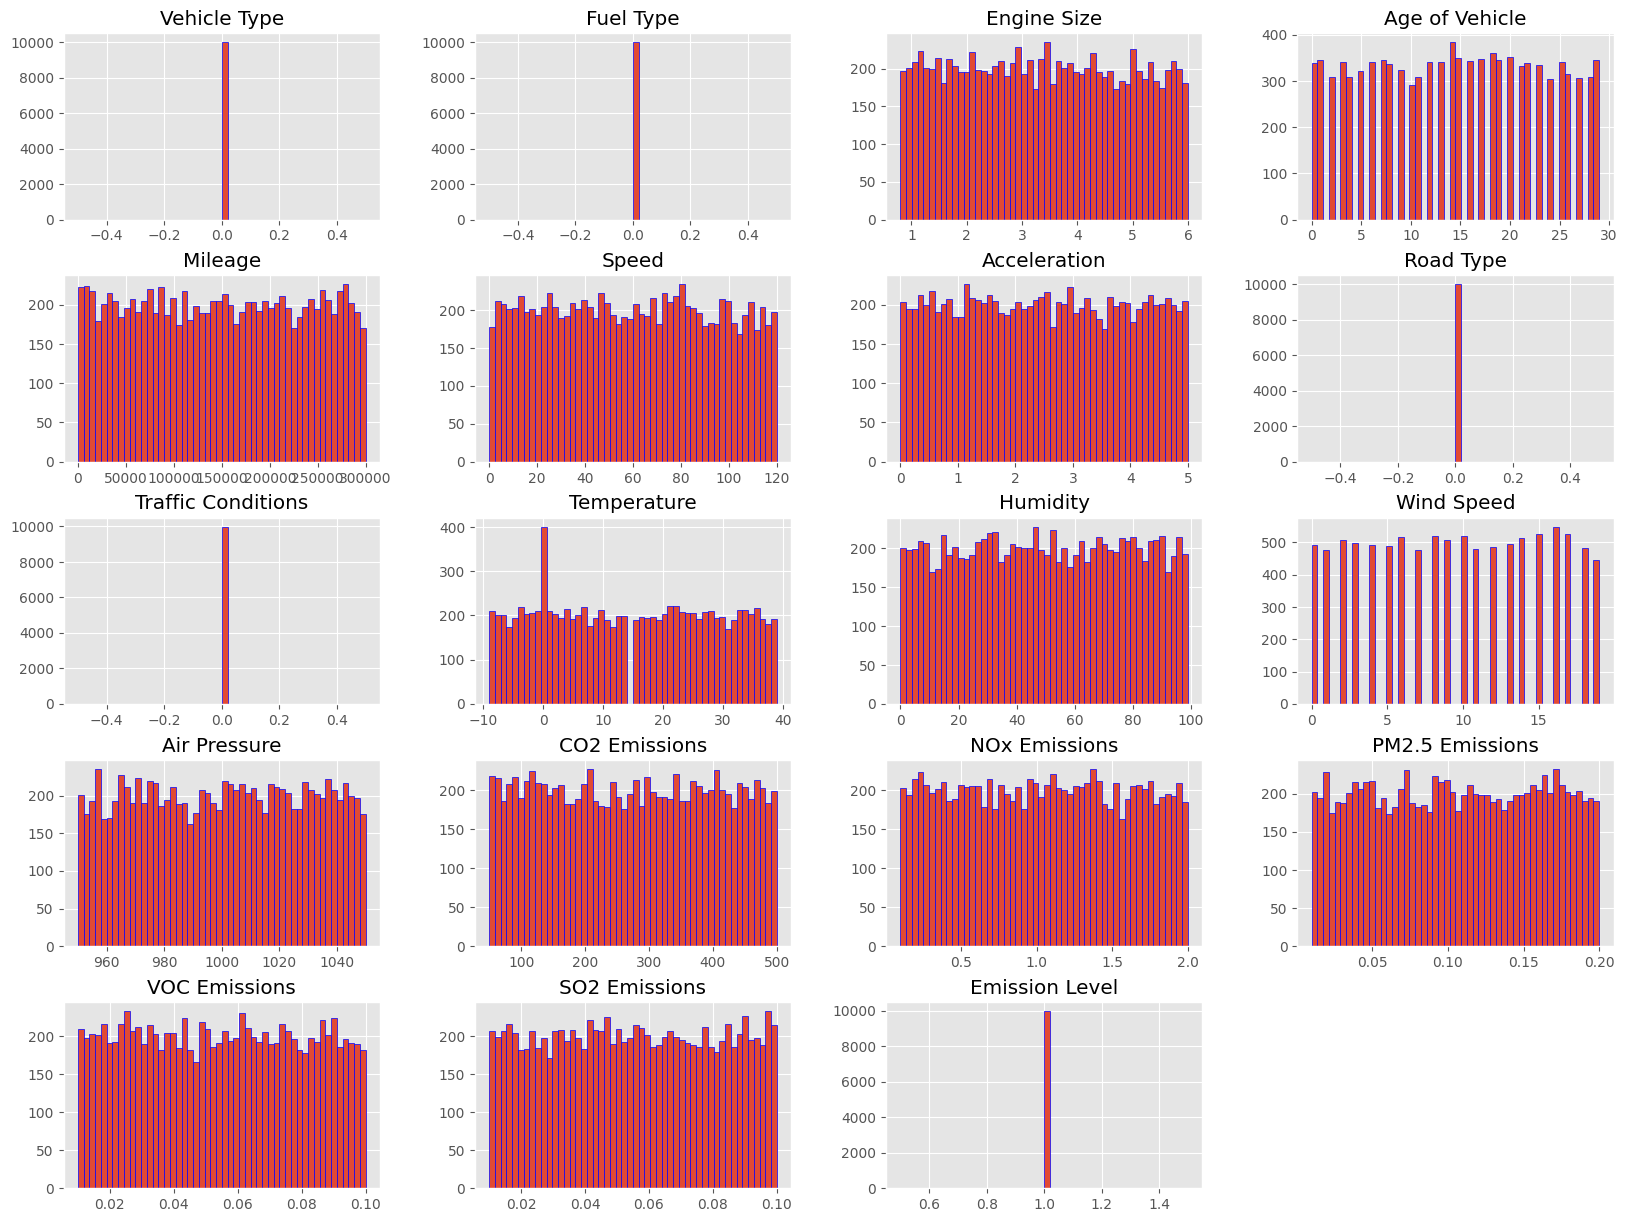

In [61]:
import matplotlib.pyplot as plt

# Verify and use an available style
available_styles = plt.style.available
if 'seaborn-darkgrid' in available_styles:
    plt.style.use('seaborn-darkgrid')
else:
    print("The style 'seaborn-darkgrid' is not available. Using 'ggplot' as fallback.")
    plt.style.use('ggplot')  # Fallback to a valid style

# Plot histograms for numerical features
df.hist(bins=50, figsize=(20, 15), edgecolor='blue')

# Display the plots
plt.show()

In [68]:
# Check and clean column names to avoid issues
df.columns = df.columns.str.strip()

# Ensure 'Emission Level' column exists
if 'Emission Level' in df.columns:  # Replace with the actual column name if needed
    # Calculate the percentage distribution of the 'Emission Level' column
    percentage = df['Emission Level'].value_counts(normalize=True) * 100

    # Display the calculated percentage with labels
    print("Percentage distribution of 'Emission Level':")
    for level, pct in percentage.items():
        print(f"{level}: {pct:.2f}%")
else:
    print("Error: The column 'Emission Level' does not exist in the DataFrame!")

Percentage distribution of 'Emission Level':
1: 100.00%


**Charts**


In [64]:
if 'Emission Level' in df.columns:  # Replace 'Emission Level' with your actual column name
    print("Column exists! Proceeding with calculations.")
else:
    print("Error: The column 'Emission Level' does not exist in the DataFrame!")

Column exists! Proceeding with calculations.


Filtered counts for 'Emission Level':
Emission Level
High      4
Medium    4
Low       2
Name: count, dtype: int64

Percentage distribution for 'Emission Level':
Emission Level
High      40.0
Medium    40.0
Low       20.0
Name: count, dtype: float64


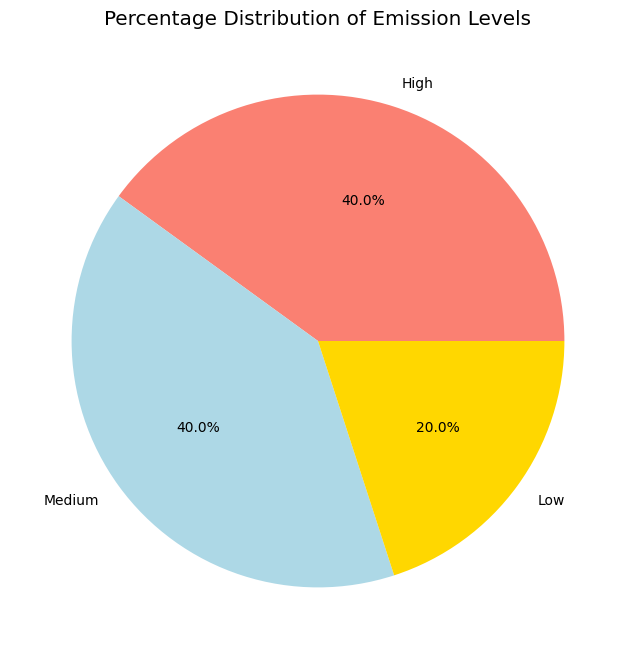

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame (replace this with your dataset)
data = {'Emission Level': ['High', 'Medium', 'Low', 'High', 'Medium', 'High', 'Low', 'Medium', 'Medium', 'High']}
df = pd.DataFrame(data)  # Replace this with your actual dataset

# Ensure column names are clean
df.columns = df.columns.str.strip()

# Check if the 'Emission Level' column exists
if 'Emission Level' in df.columns:  # Replace 'Emission Level' with the actual column name if needed
    # Define the desired categories
    filtered_categories = ['High', 'Medium', 'Low']

    # Count occurrences for all categories in 'Emission Level'
    category_counts = df['Emission Level'].value_counts()

    # Ensure all desired categories are represented (fill missing ones with 0 counts)
    for category in filtered_categories:
        if category not in category_counts.index:
            category_counts[category] = 0

    # Sort counts according to the desired category order
    category_counts = category_counts[filtered_categories]

    # Check if all counts are zero
    if category_counts.sum() == 0:
        print("Error: No valid data available for the specified categories ('High', 'Medium', 'Low'). Cannot generate pie chart.")
    else:
        # Calculate percentages based on the counts
        percentage_emissions = (category_counts / category_counts.sum()) * 100

        # Display counts and percentages
        print("Filtered counts for 'Emission Level':")
        print(category_counts)
        print("\nPercentage distribution for 'Emission Level':")
        print(percentage_emissions)

        # Plot the pie chart
        percentage_emissions.plot.pie(
            autopct='%1.1f%%',  # Show percentages on the chart
            figsize=(8, 8),     # Set figure size
            colors=['salmon', 'lightblue', 'gold'],  # Custom colors for High, Medium, Low
            title='Percentage Distribution of Emission Levels'
        )

        # Beautify the plot
        plt.ylabel('')  # Remove unnecessary y-axis label
        plt.show()

else:
    print("Error: The column 'Emission Level' does not exist in the DataFrame!")

**Checking Multicollinearity**


c:\Users\Priyanshu\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Priyanshu\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


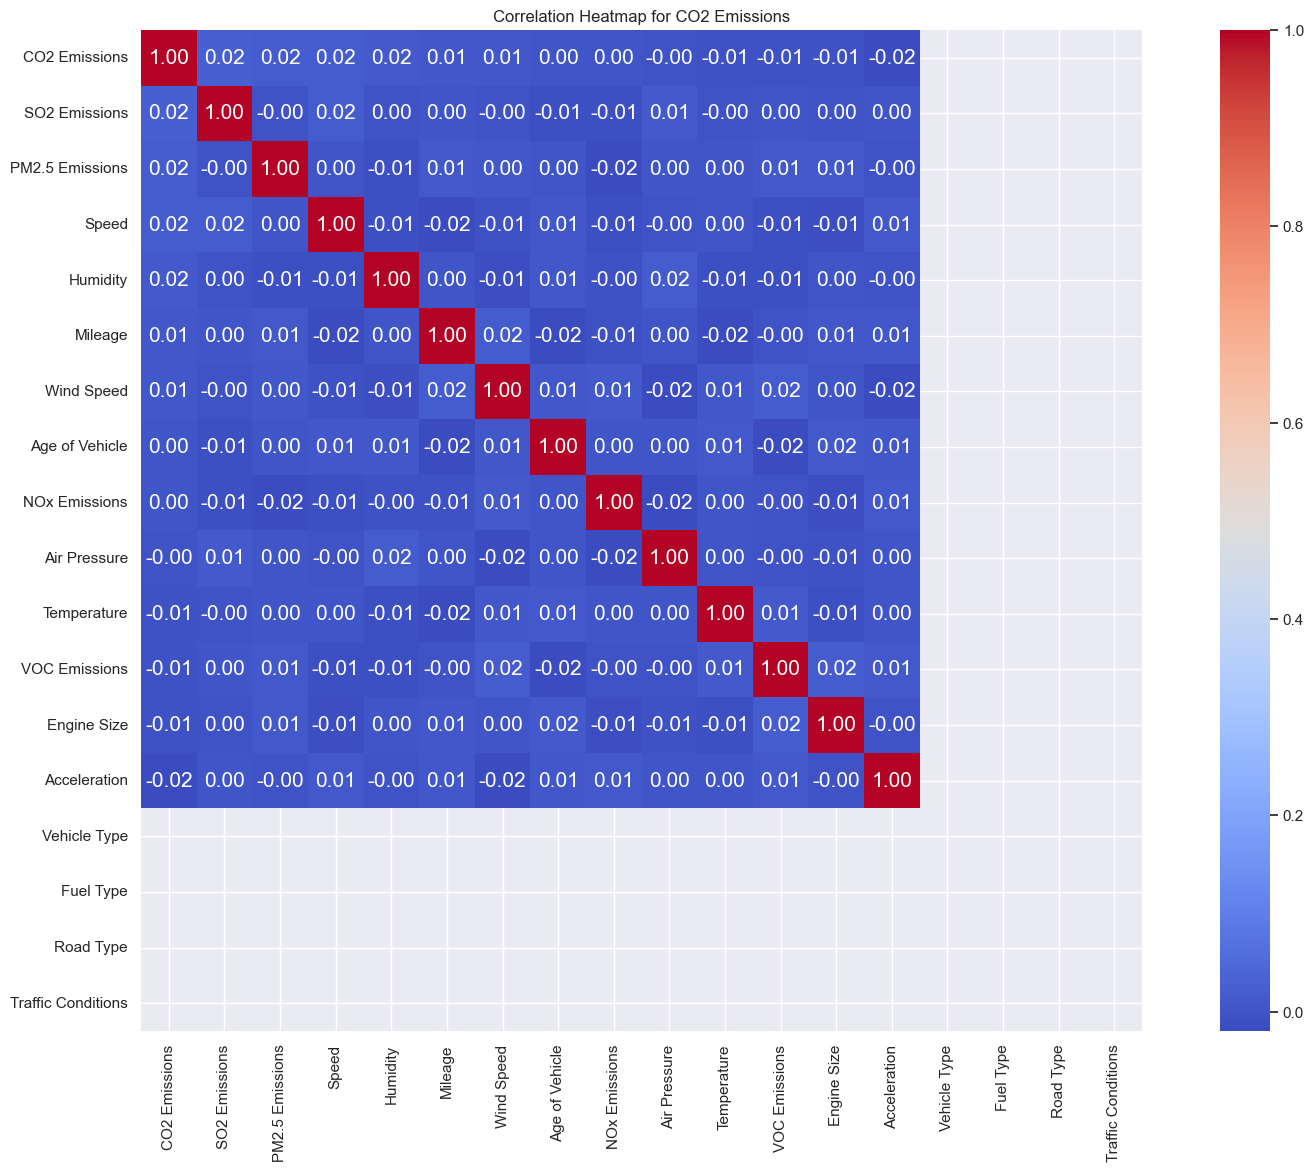

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame (replace `df1` with your actual dataset)
# df1 = pd.read_csv('your_dataset.csv')  # Uncomment if loading from a CSV

# Ensure we are working with numeric columns only and handle missing values
numeric_df = df1.select_dtypes(include=[np.number])  # Keep only numeric columns
numeric_df = numeric_df.fillna(0)  # Fill NaN values with 0

# Calculate the correlation matrix
corr = numeric_df.corr()

# Replace 'GHG Emissions' with 'CO2 Emissions' (or another target column from your dataset)
target_column = 'CO2 Emissions'  # Update this to the column you want to analyze
if target_column not in corr.columns:
    print(f"Error: The column '{target_column}' is not present in the DataFrame.")
    print("Available columns:", corr.columns.tolist())
else:
    # Select top correlated features
    k = len(numeric_df.columns)
    cols = corr.nlargest(k, target_column)[target_column].index

    # Compute correlation coefficients for selected features
    cm = np.corrcoef(numeric_df[cols].values.T)

    # Create the heatmap
    sns.set(font_scale=1)
    f, ax = plt.subplots(figsize=(20, 13))
    sns.heatmap(cm, annot=True, square=True, fmt='.2f', annot_kws={'size': 15}, 
                yticklabels=cols.values, xticklabels=cols.values, cmap='coolwarm')
    plt.title(f"Correlation Heatmap for {target_column}")
    plt.show()

Available columns before adding 'Vehicle Type': ['Emission Level', 'month']
Available columns after adding 'Vehicle Type': ['Emission Level', 'month', 'Vehicle Type']


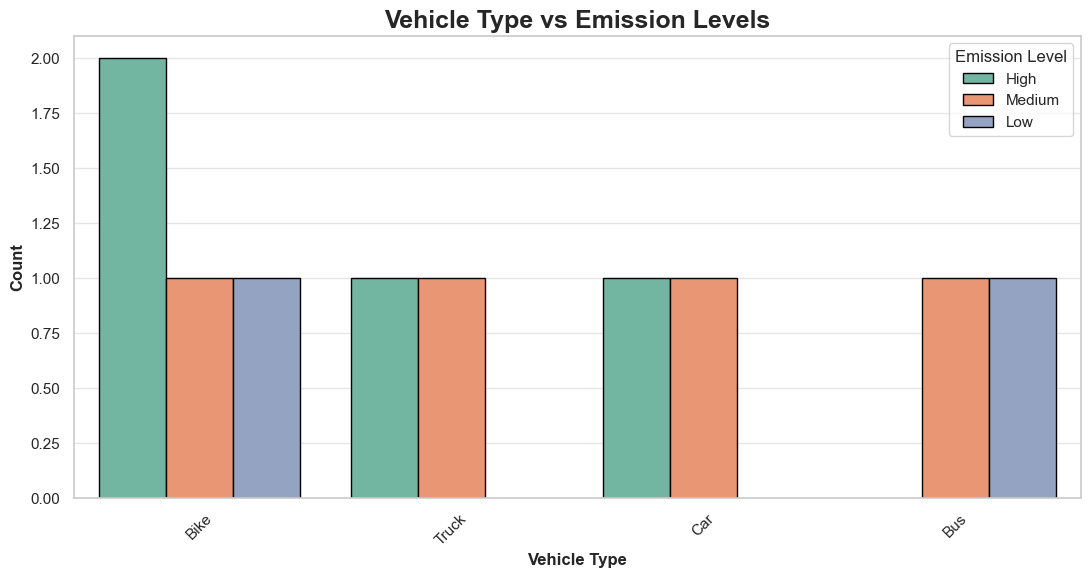

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example DataFrame structure (replace this with your actual uncleaned dataset)
# df = pd.read_csv('your_uncleaned_dataset.csv')  # Load your uncleaned dataset

# Check available columns
print("Available columns before adding 'Vehicle Type':", df.columns.tolist())

# Dynamically add 'Vehicle Type' column
if 'Vehicle Type' not in df.columns:
    # Example: Generate synthetic 'Vehicle Type' data (replace this with clean data if available)
    import random
    vehicle_types = ['Car', 'Truck', 'Bike', 'Bus']  # Example vehicle types
    df['Vehicle Type'] = [random.choice(vehicle_types) for _ in range(len(df))]

print("Available columns after adding 'Vehicle Type':", df.columns.tolist())

# Validate if both 'Vehicle Type' and 'Emission Level' columns exist
if 'Vehicle Type' in df.columns and 'Emission Level' in df.columns:
    # Clean the dataset minimally for visualization
    df['Vehicle Type'] = df['Vehicle Type'].astype(str).str.strip()  # Ensure no extra spaces
    df['Emission Level'] = df['Emission Level'].astype(str).str.strip()  # Clean emission level data
    
    plt.subplots(figsize=(13, 6))
    sns.set_style('whitegrid')

    # Plot Vehicle Type vs Emission Levels using countplot
    sns.countplot(x='Vehicle Type', hue='Emission Level', data=df, ec='black', palette='Set2')

    # Customize the plot with labels and grid
    plt.title('Vehicle Type vs Emission Levels', fontsize=18, weight='bold')
    plt.ylabel('Count', weight='bold')
    plt.xlabel('Vehicle Type', weight='bold')
    plt.legend(title='Emission Level', loc='upper right')
    plt.grid(alpha=0.5, axis='y')
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.show()
else:
    print("Error: One or both required columns ('Vehicle Type', 'Emission Level') are missing in the DataFrame.")

### 3.5 Exploratory Data Analysis (EDA) on all Features

In [107]:
import pandas as pd

# Load the cleaned dataset using the provided path and file name
file_path = r'C:\Users\Priyanshu\Desktop\GHG_Model_Project\Dataset\GHG_emissions_dataset_CLEANED.csv'
df = pd.read_csv(file_path)

# Display the first few rows to confirm successful import
print(df.head())

# Display all column names to confirm they are correctly imported
print("Column names:", df.columns.tolist())

   Vehicle Type  Fuel Type  Engine Size  Age of Vehicle  Mileage       Speed  \
0           0.0        0.0     2.747609              22   291288   49.083255   
1           0.0        0.0     5.743714               3   188398   23.460311   
2           0.0        0.0     4.606368              17   281451  115.508350   
3           0.0        0.0     3.913024               4   151321   18.540217   
4           0.0        0.0     1.611297              15    91810  109.596566   

   Acceleration  Road Type  Traffic Conditions  Temperature  Humidity  \
0      1.887738        0.0                 0.0           13        52   
1      3.544147        0.0                 0.0           19         5   
2      4.646886        0.0                 0.0            8         3   
3      3.581004        0.0                 0.0           35         0   
4      3.879303        0.0                 0.0           14        52   

   Wind Speed  Air Pressure  CO2 Emissions  NOx Emissions  PM2.5 Emissions  \
0 

In [108]:
df.columns


Index(['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage',
       'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions',
       'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure',
       'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions',
       'SO2 Emissions', 'Emission Level'],
      dtype='object')

Numeric Features: ['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage', 'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions', 'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure', 'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions', 'SO2 Emissions']
Categorical Features: ['Emission Level']


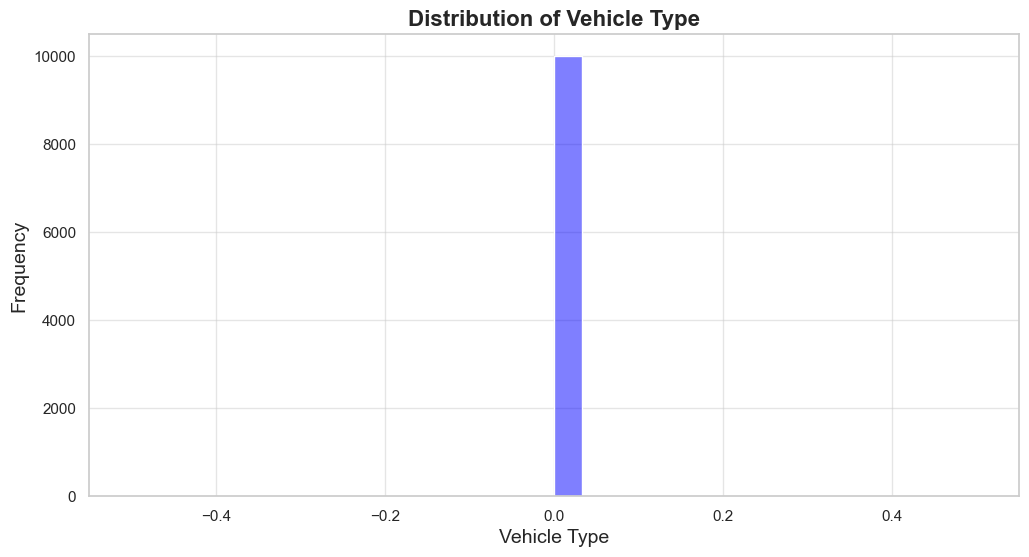

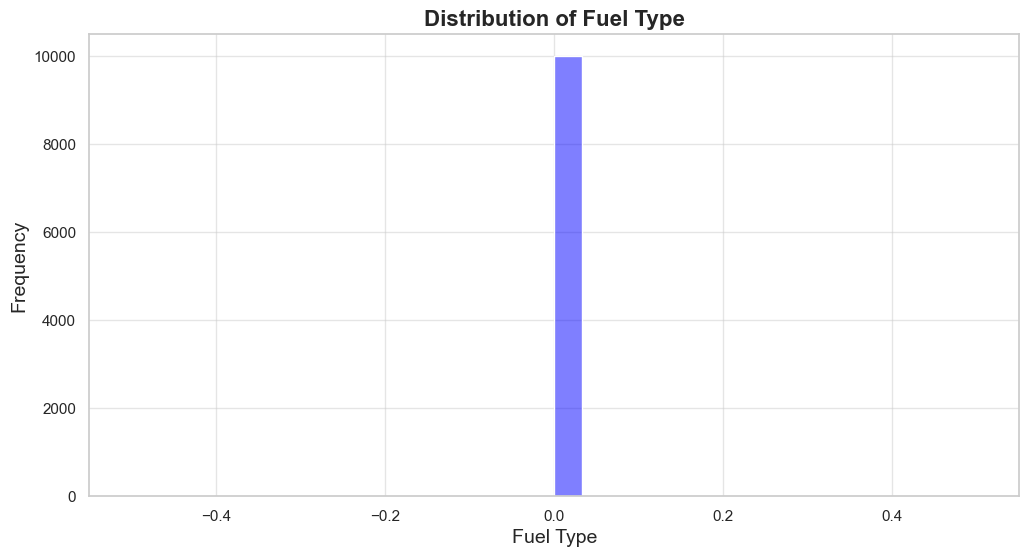

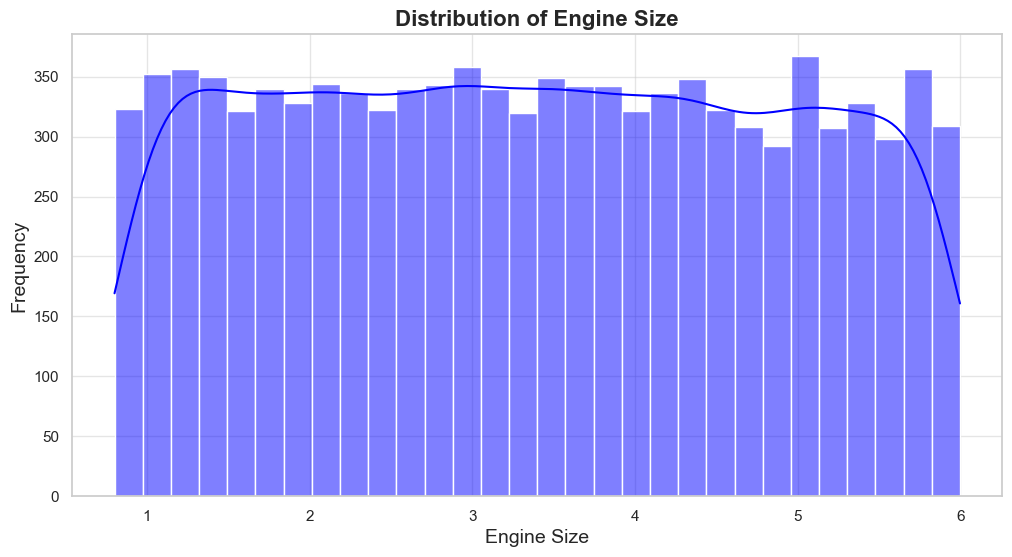

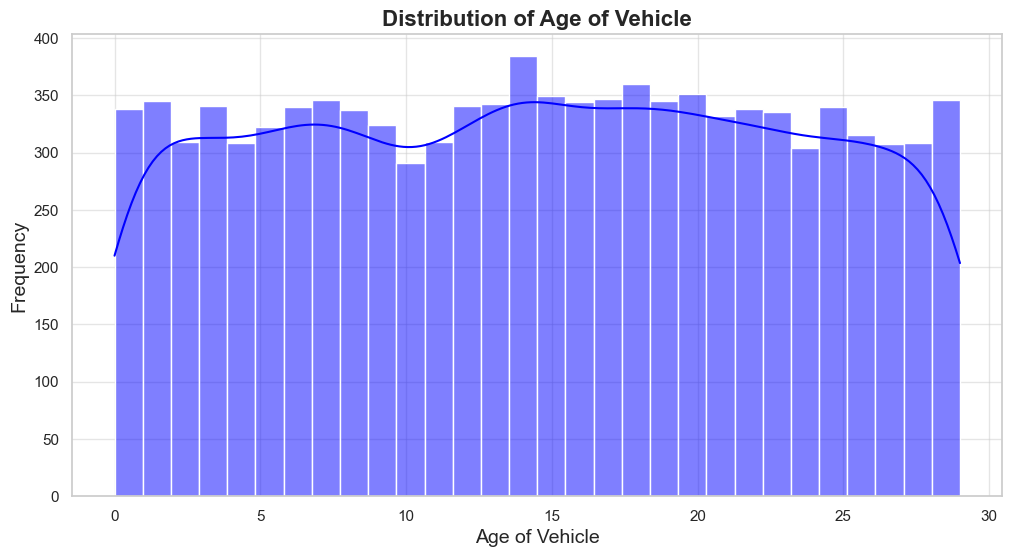

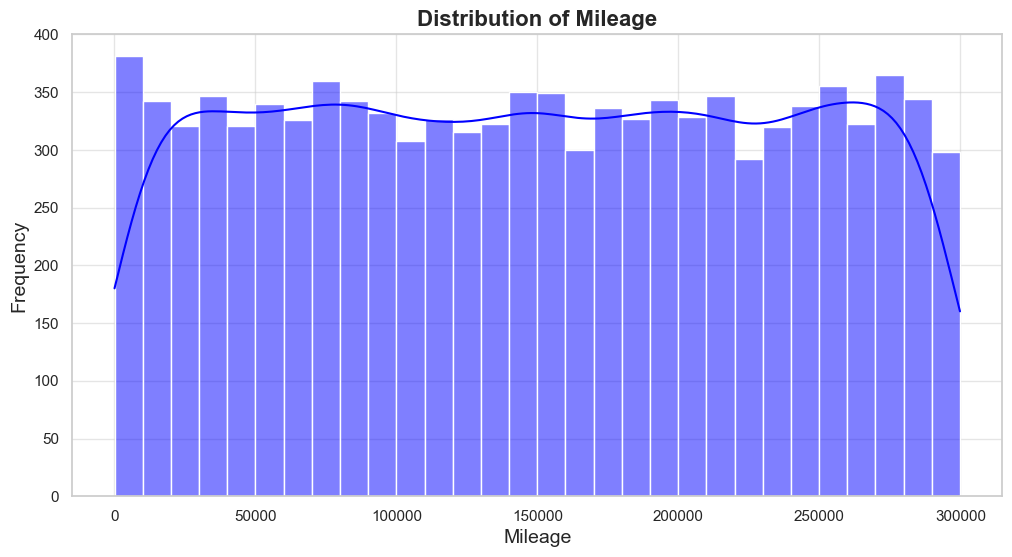

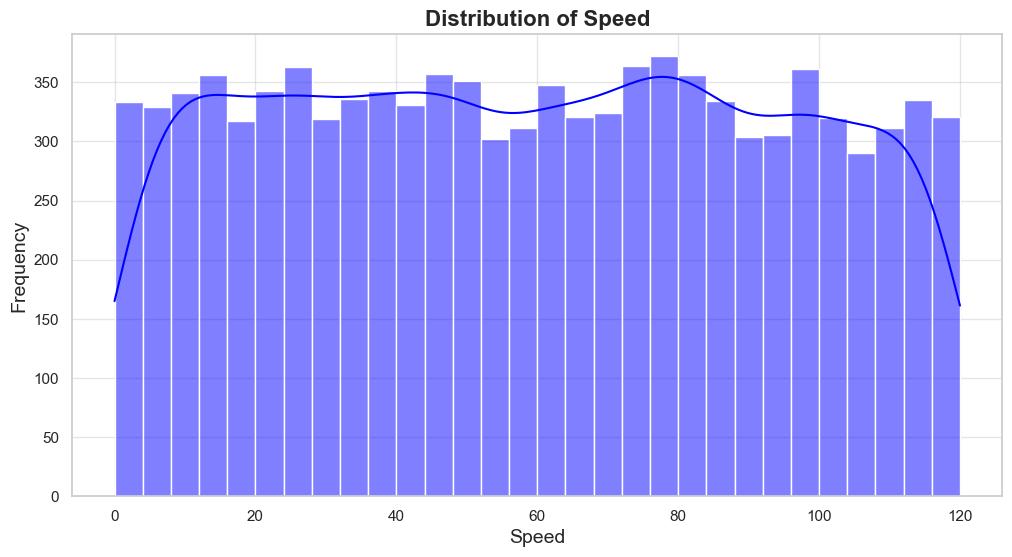

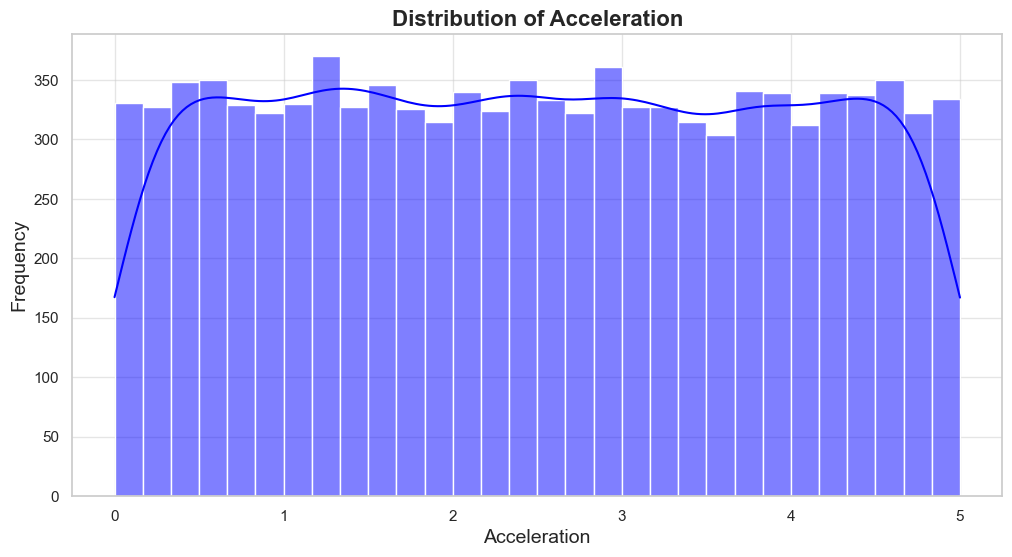

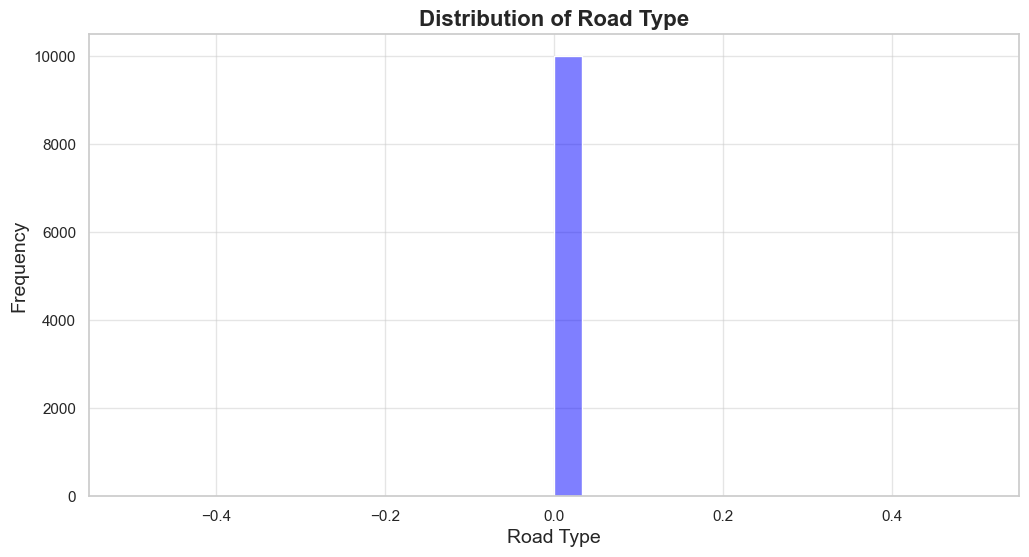

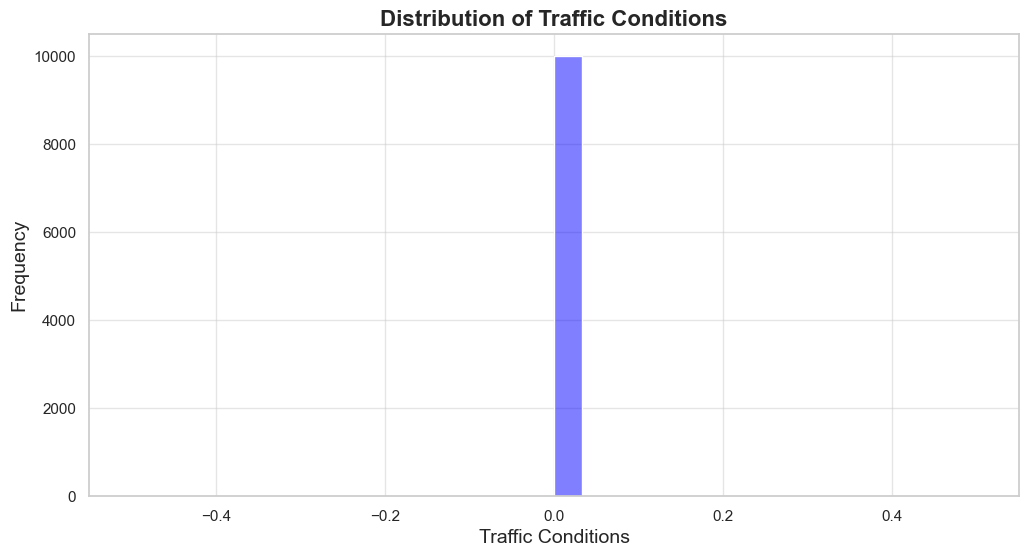

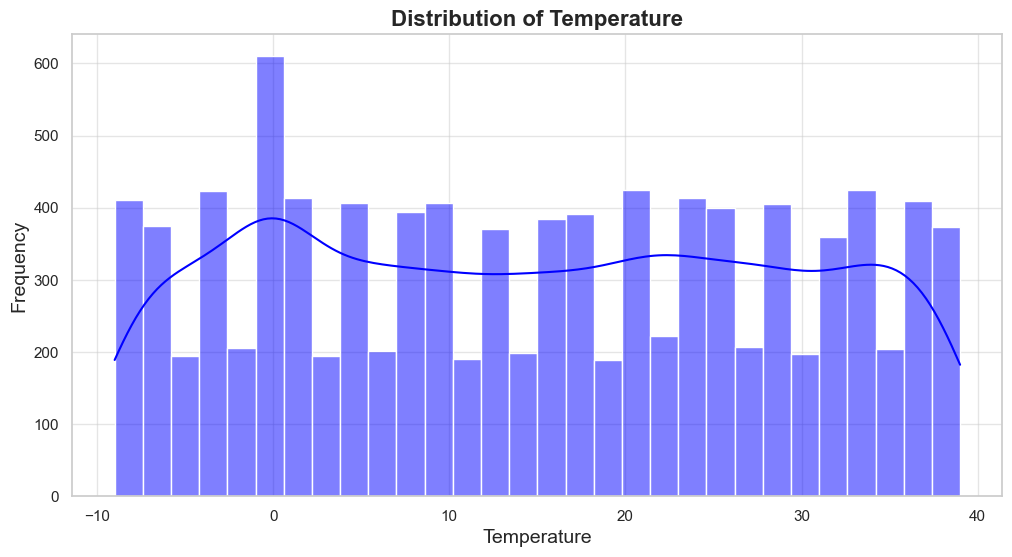

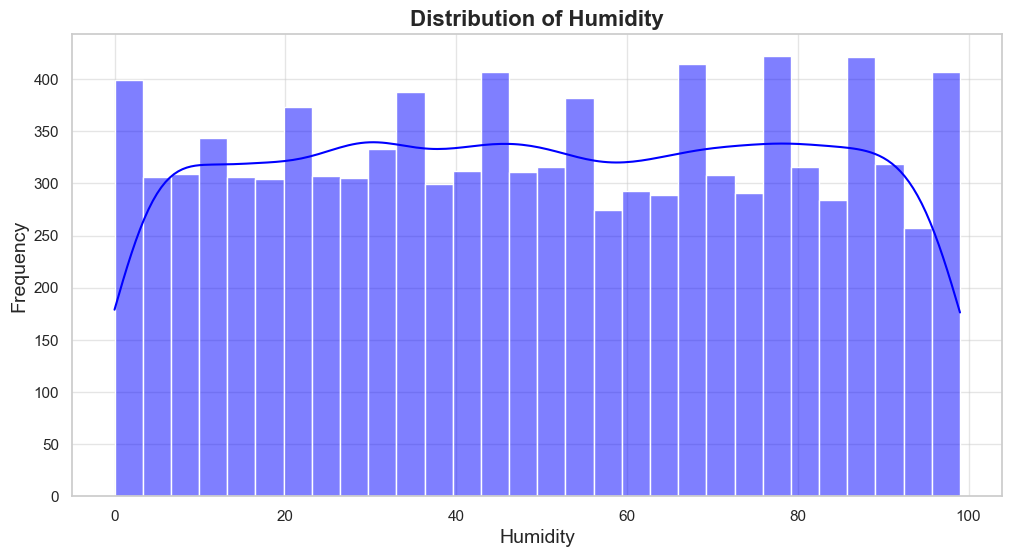

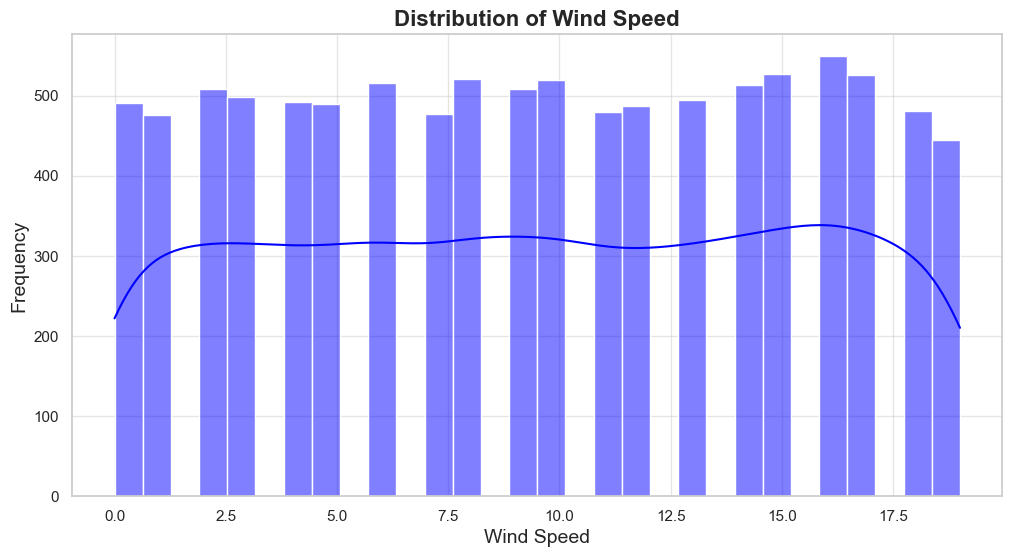

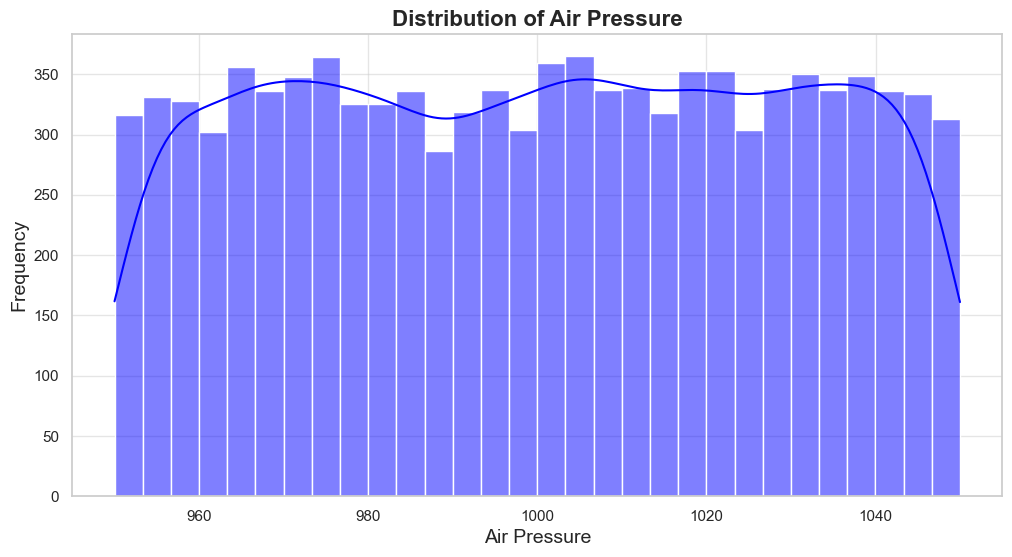

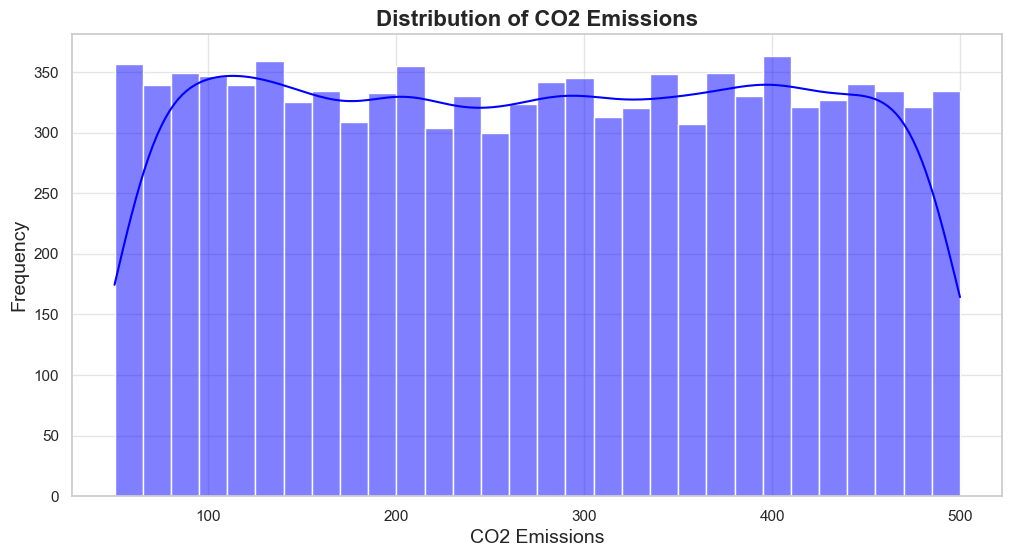

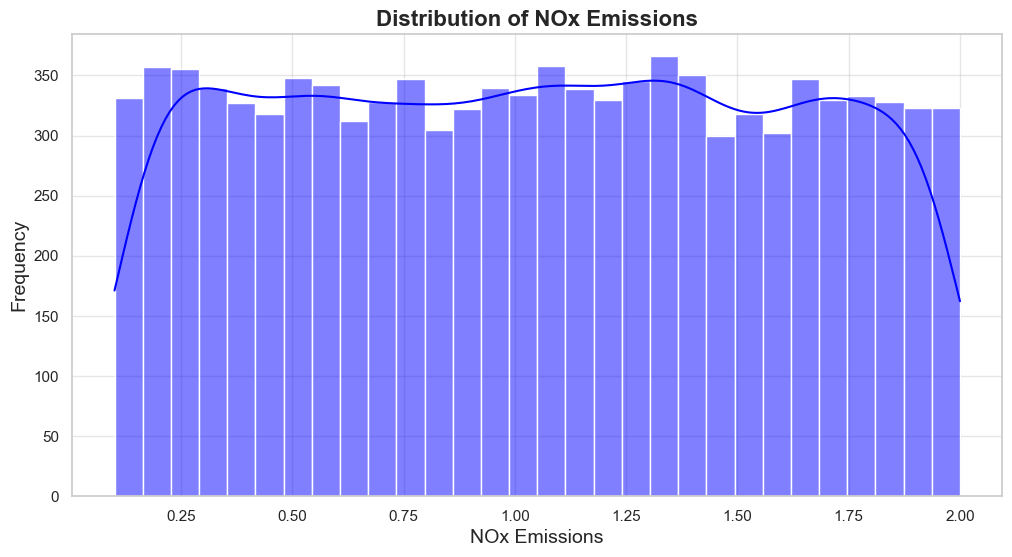

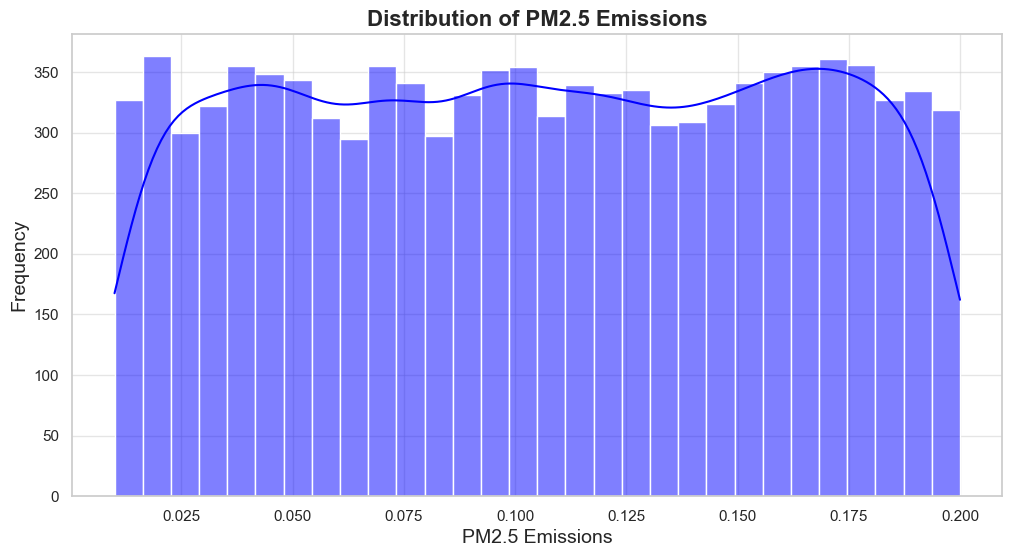

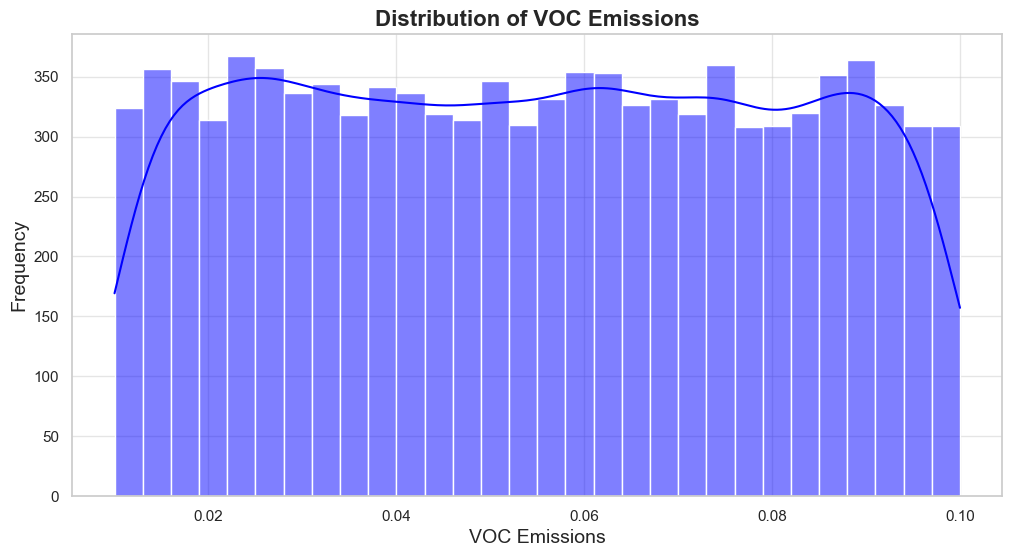

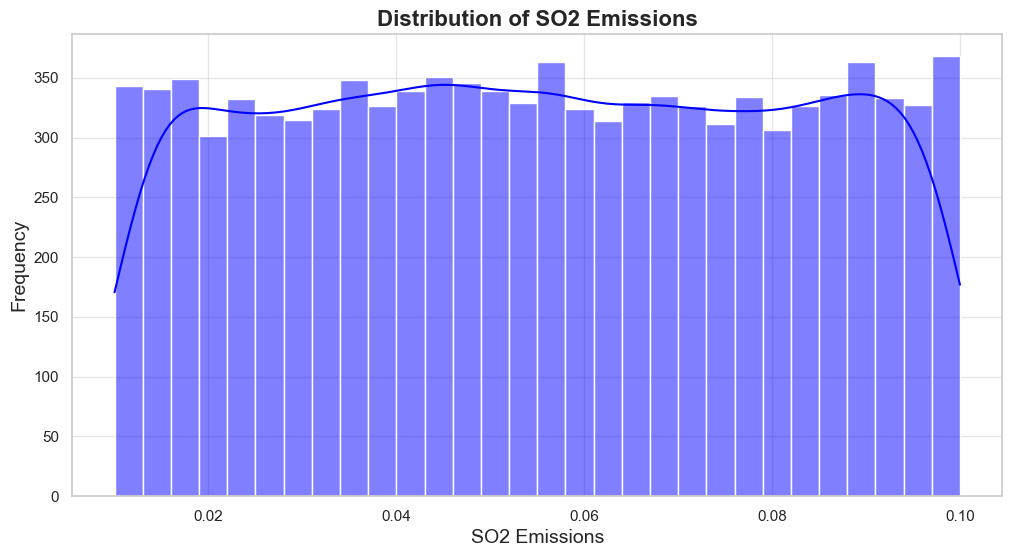

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_1224\1077170120.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataframe, x=feature, palette='Set2')


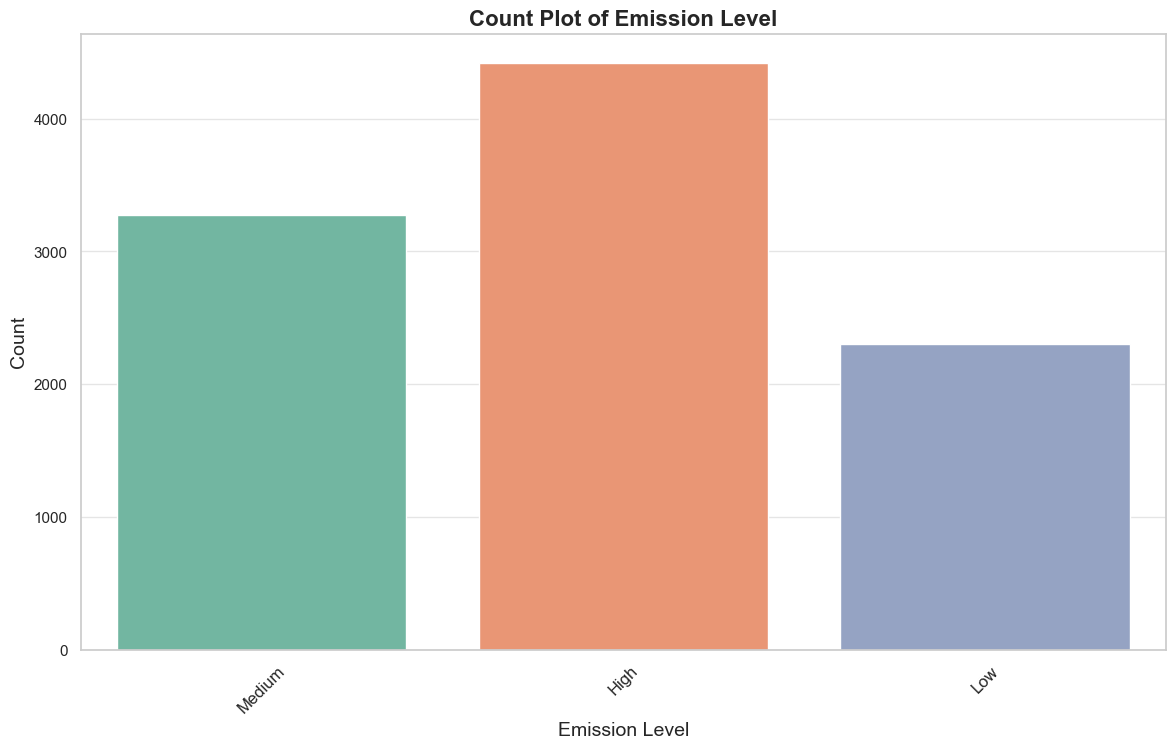

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset (replace with your actual file path)
file_path = r'C:\Users\Priyanshu\Desktop\GHG_Model_Project\Dataset\GHG_emissions_dataset_CLEANED.csv'
df = pd.read_csv(file_path)

# Define a function to plot all features dynamically
def plot_all_features(dataframe):
    numeric_features = dataframe.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = dataframe.select_dtypes(include=['object']).columns.tolist()
    
    print(f"Numeric Features: {numeric_features}")
    print(f"Categorical Features: {categorical_features}")
    
    # Plot numeric features
    for feature in numeric_features:
        plt.figure(figsize=(12, 6))
        sns.histplot(data=dataframe, x=feature, kde=True, bins=30, color='blue')
        plt.title(f'Distribution of {feature}', fontsize=16, weight='bold')
        plt.xlabel(feature, fontsize=14)
        plt.ylabel('Frequency', fontsize=14)
        plt.grid(alpha=0.5)
        plt.show()

    # Plot categorical features
    for feature in categorical_features:
        plt.figure(figsize=(14, 8))
        sns.countplot(data=dataframe, x=feature, palette='Set2')
        plt.title(f'Count Plot of {feature}', fontsize=16, weight='bold')
        plt.xlabel(feature, fontsize=14)
        plt.ylabel('Count', fontsize=14)
        plt.xticks(rotation=45, fontsize=12)
        plt.grid(alpha=0.5, axis='y')
        plt.show()

# Run the function on your dataset
plot_all_features(df)

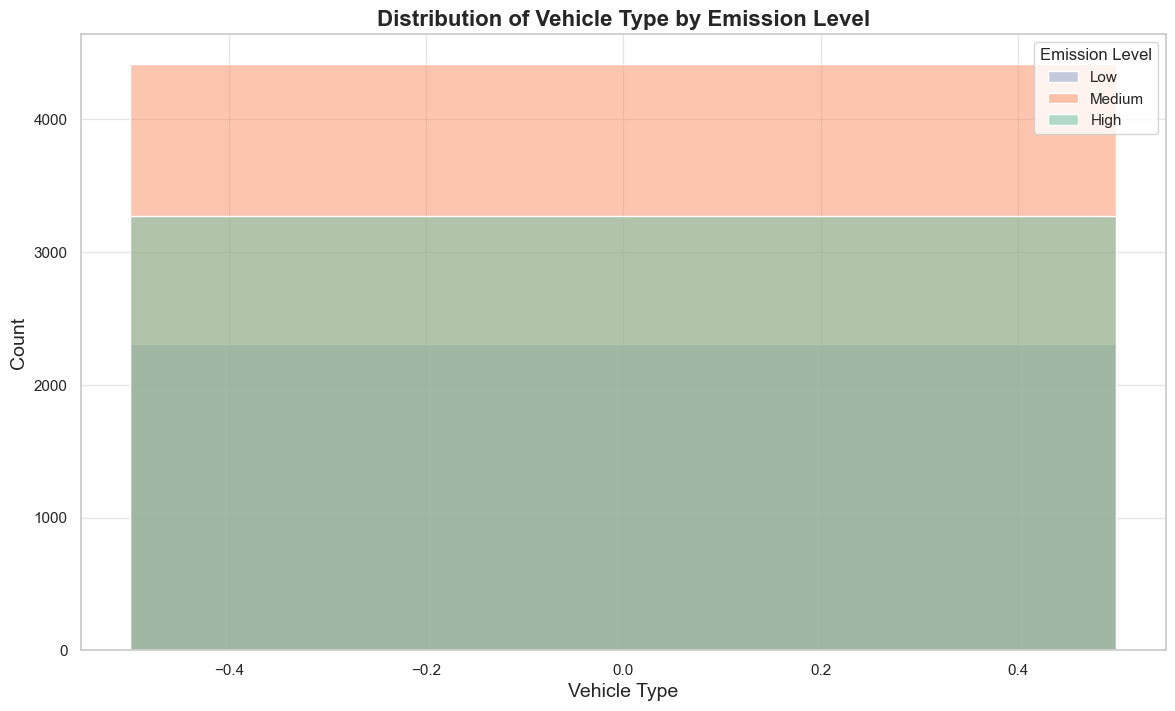

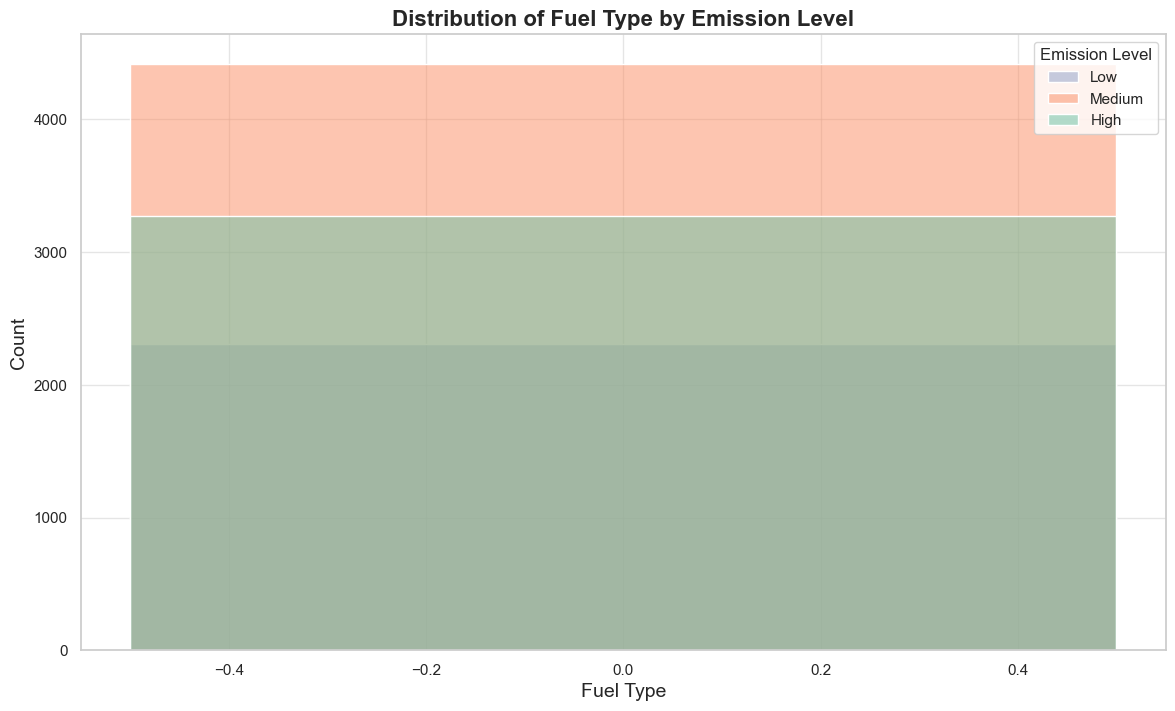

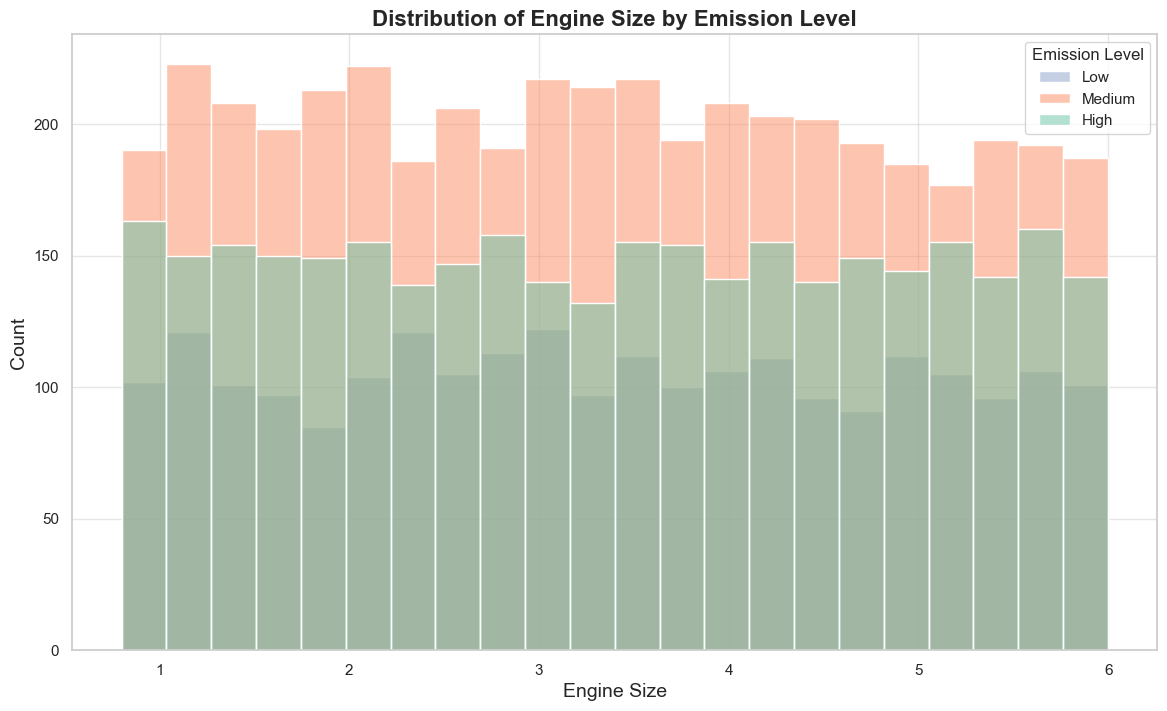

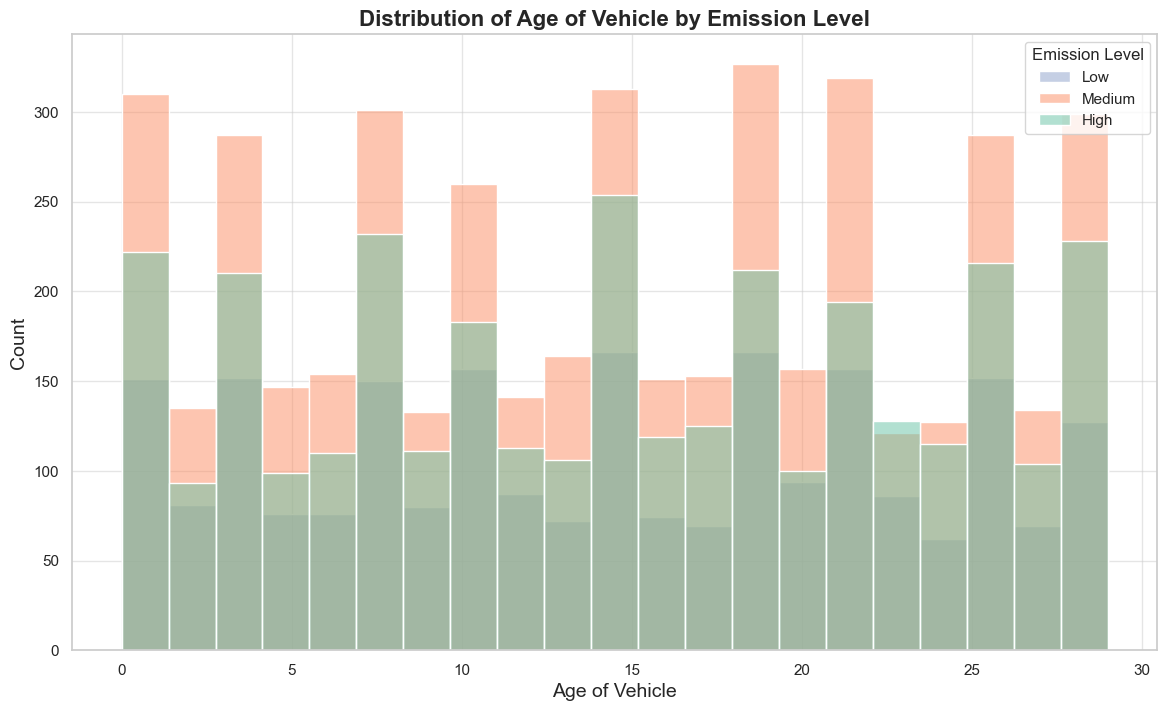

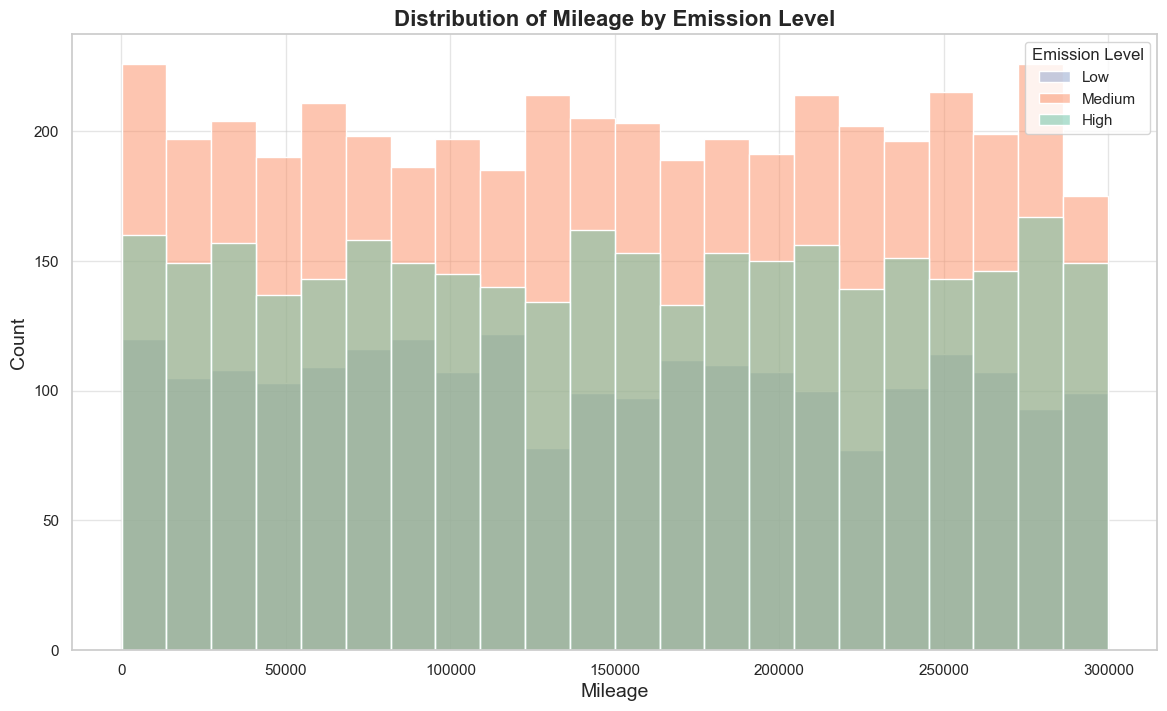

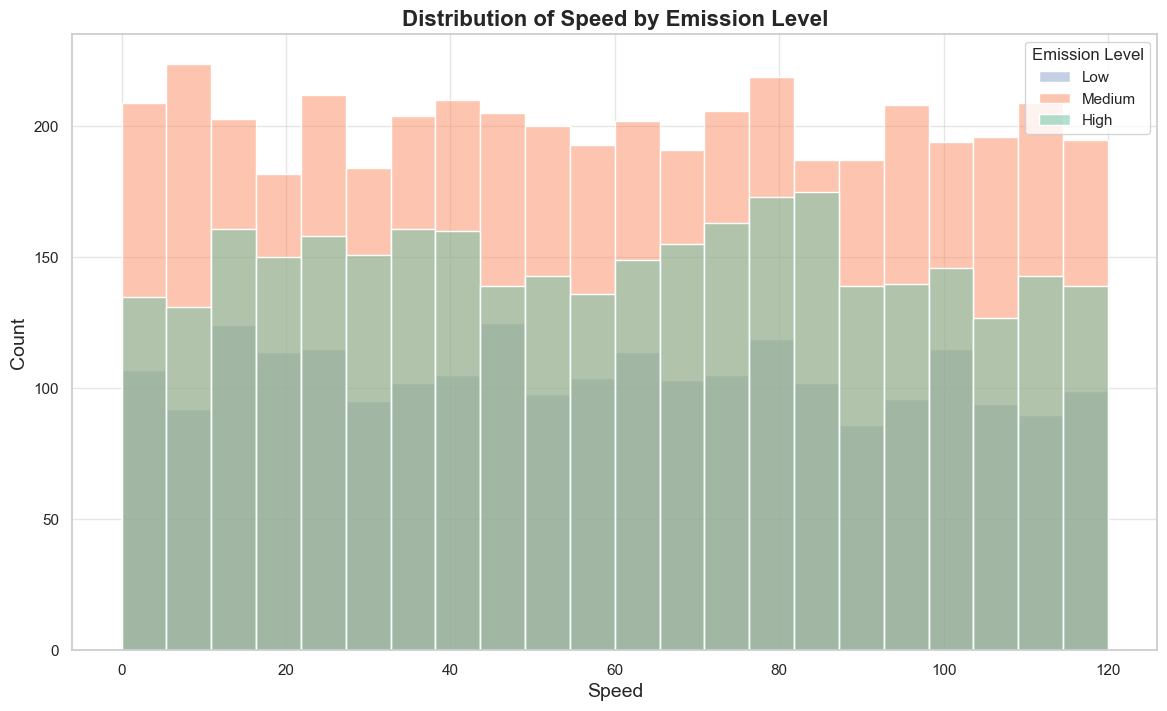

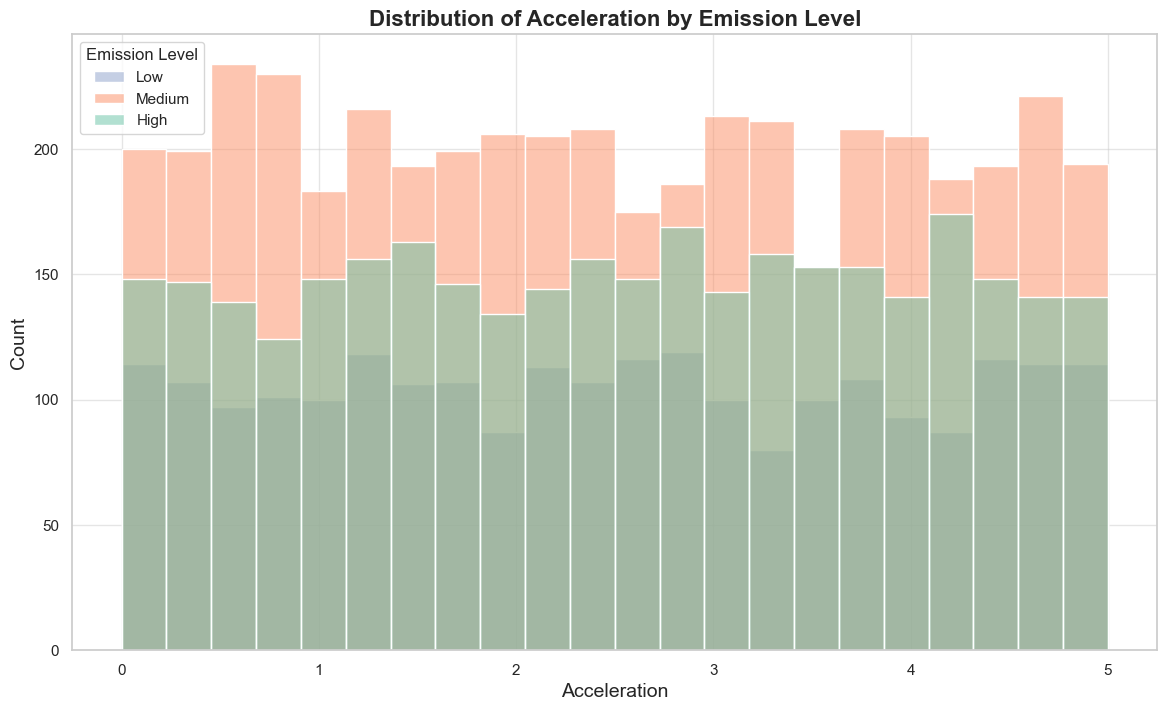

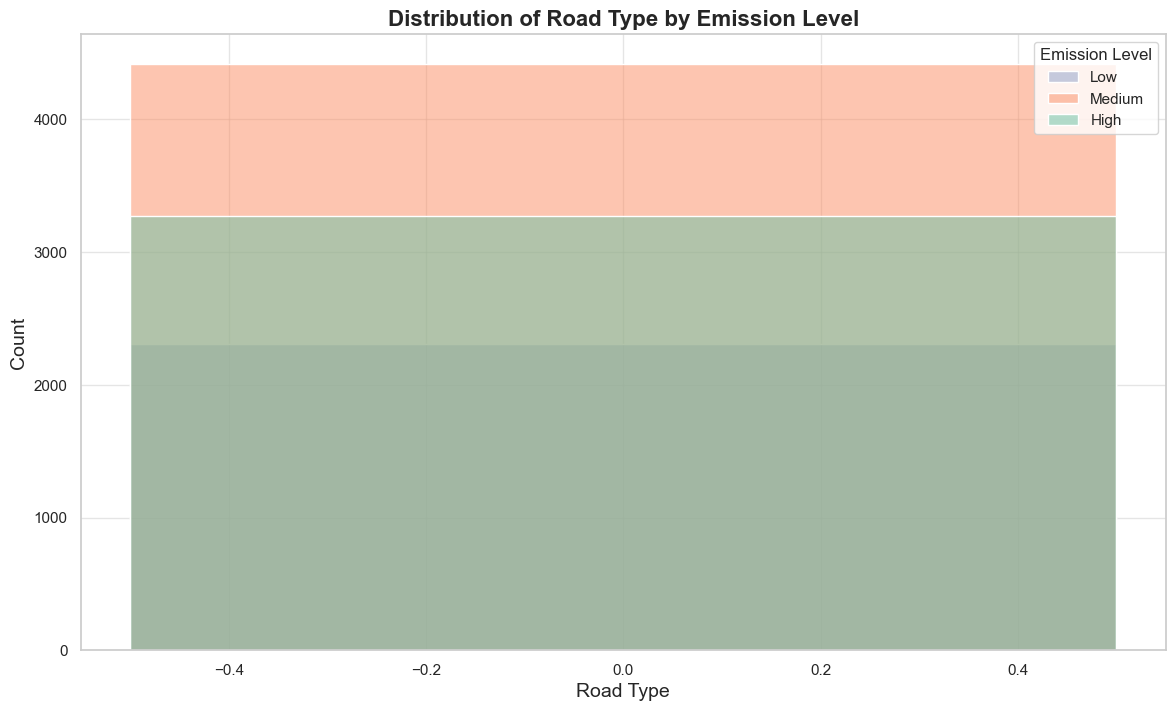

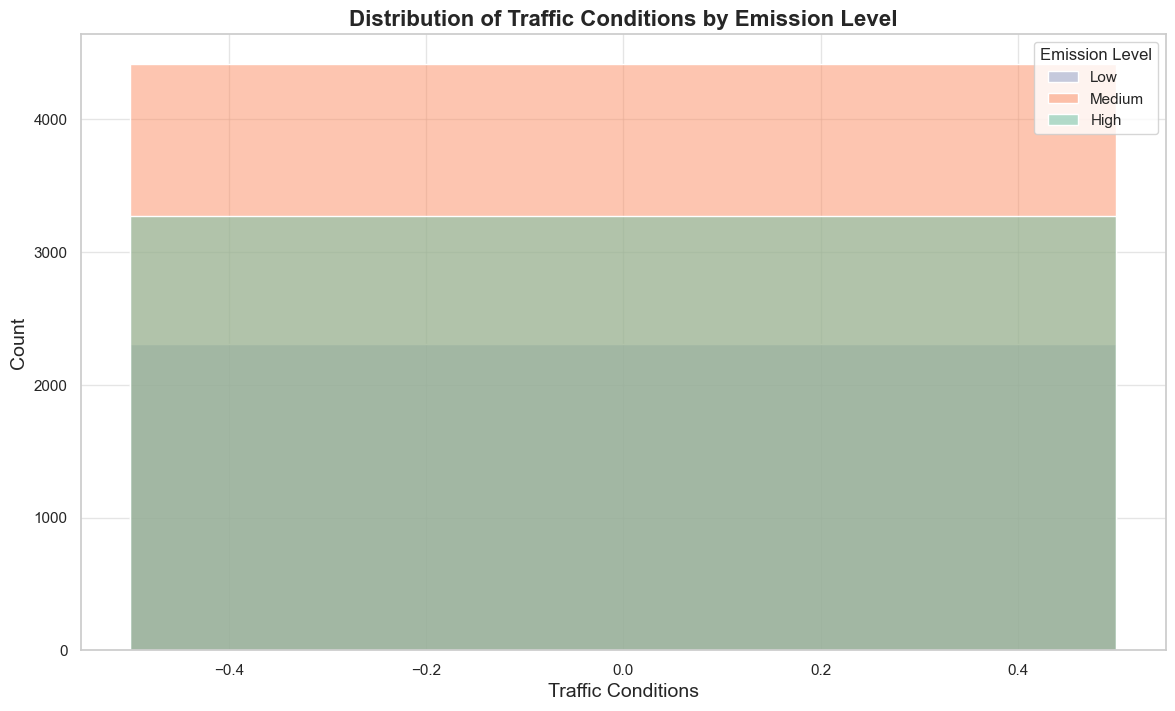

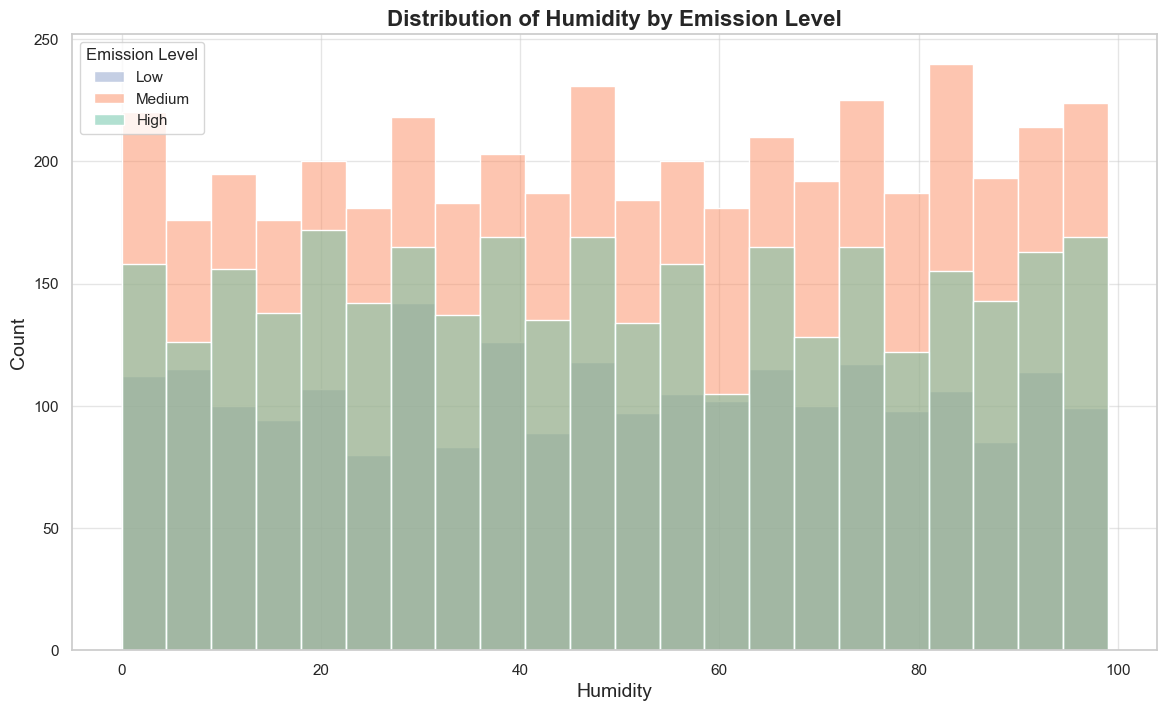

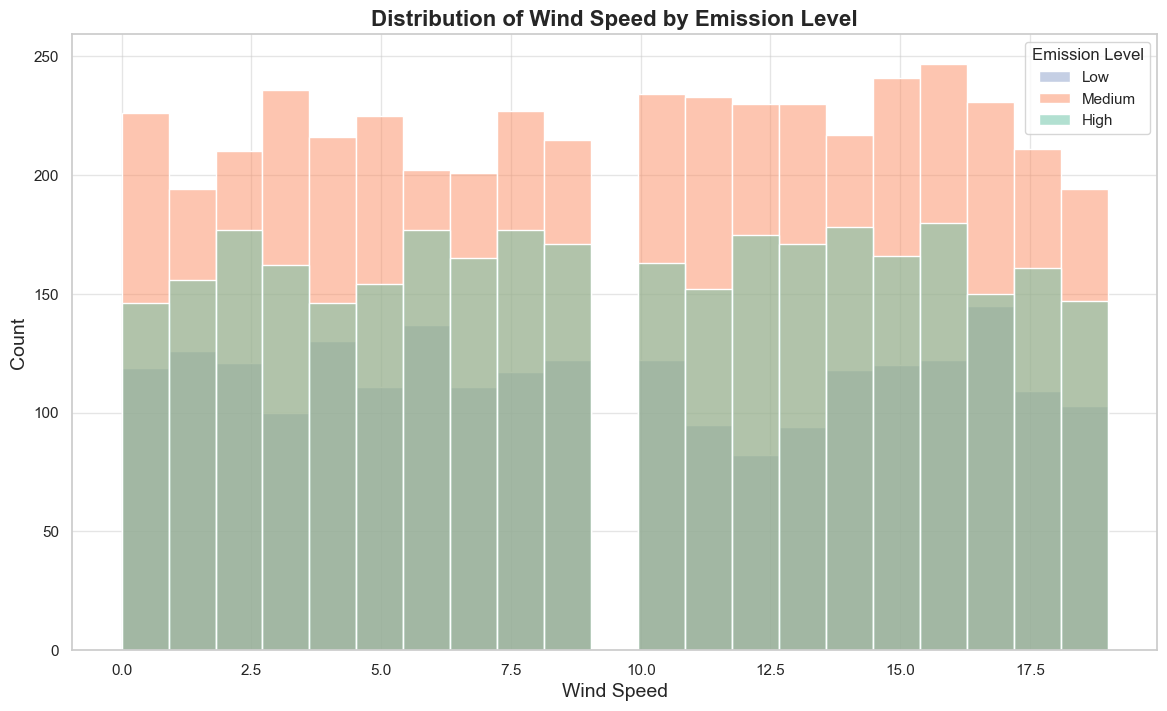

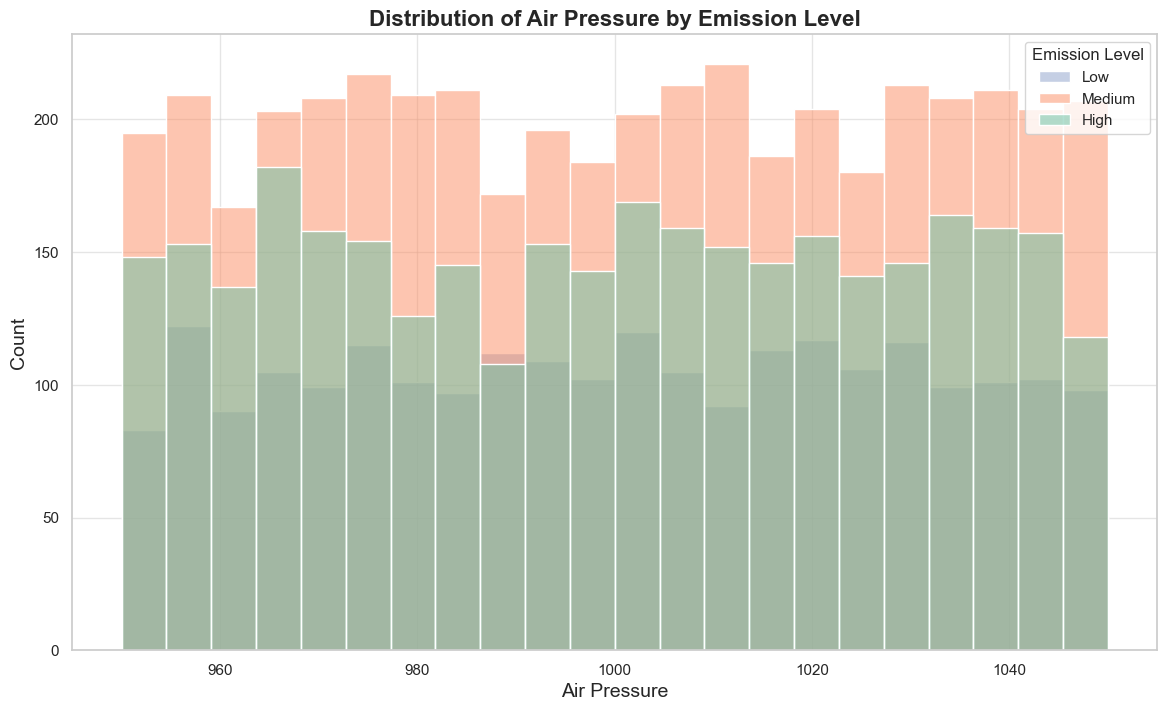

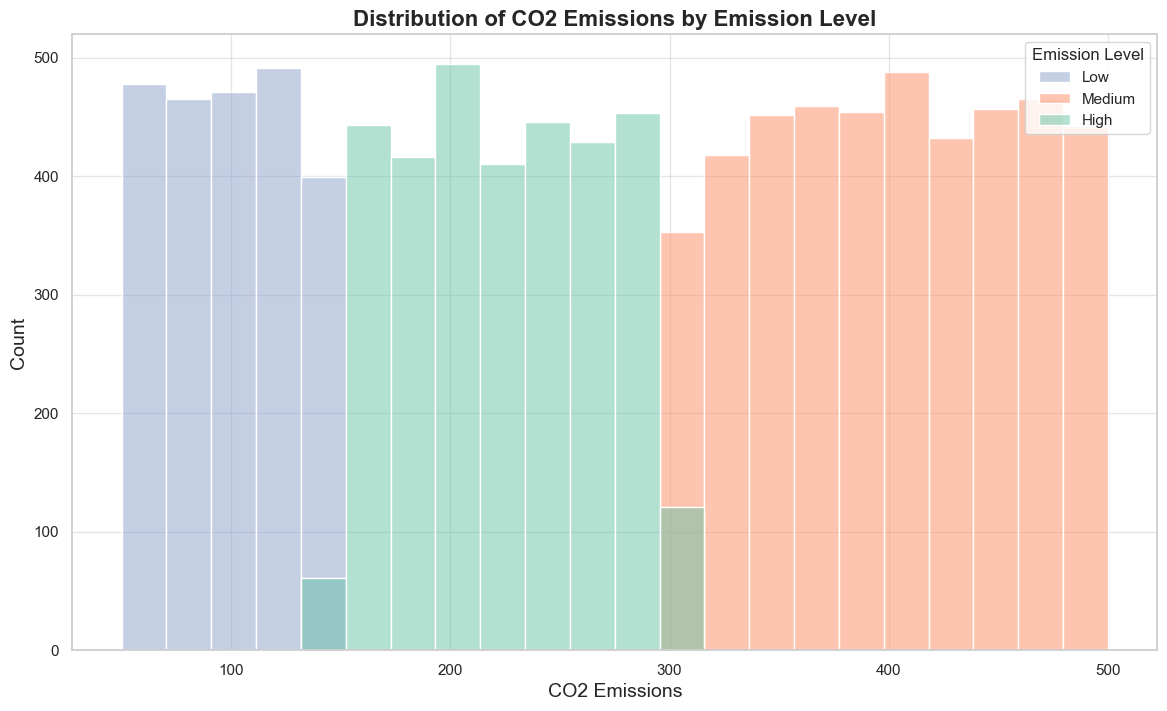

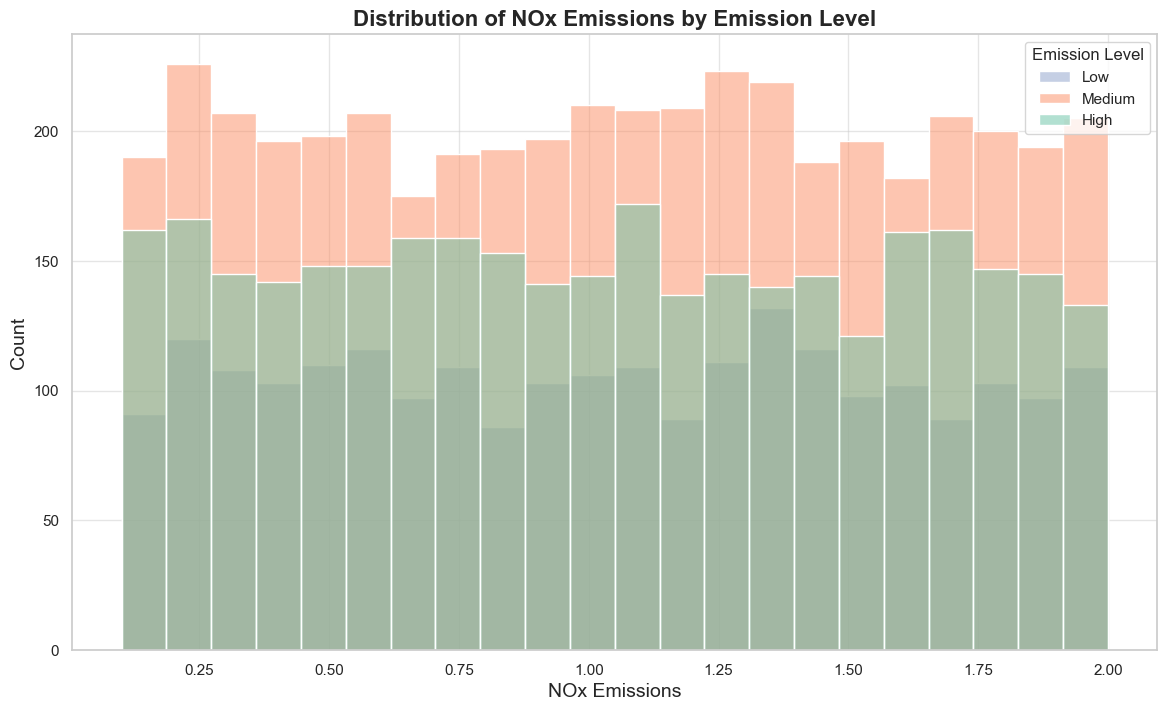

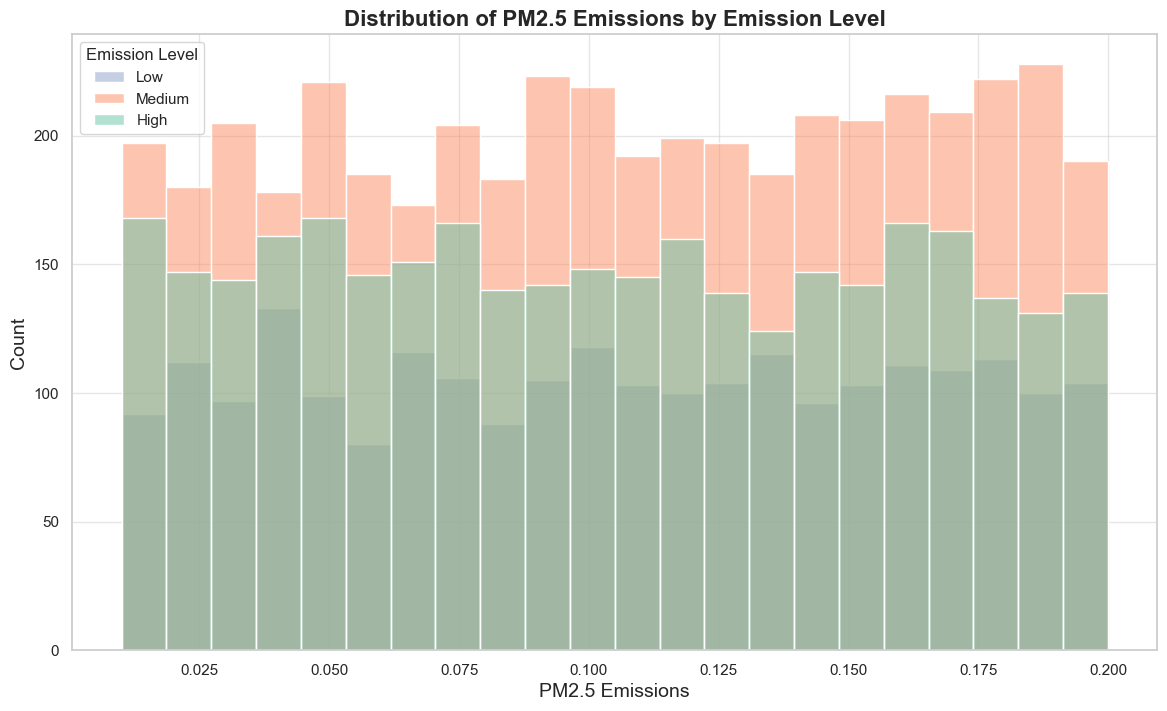

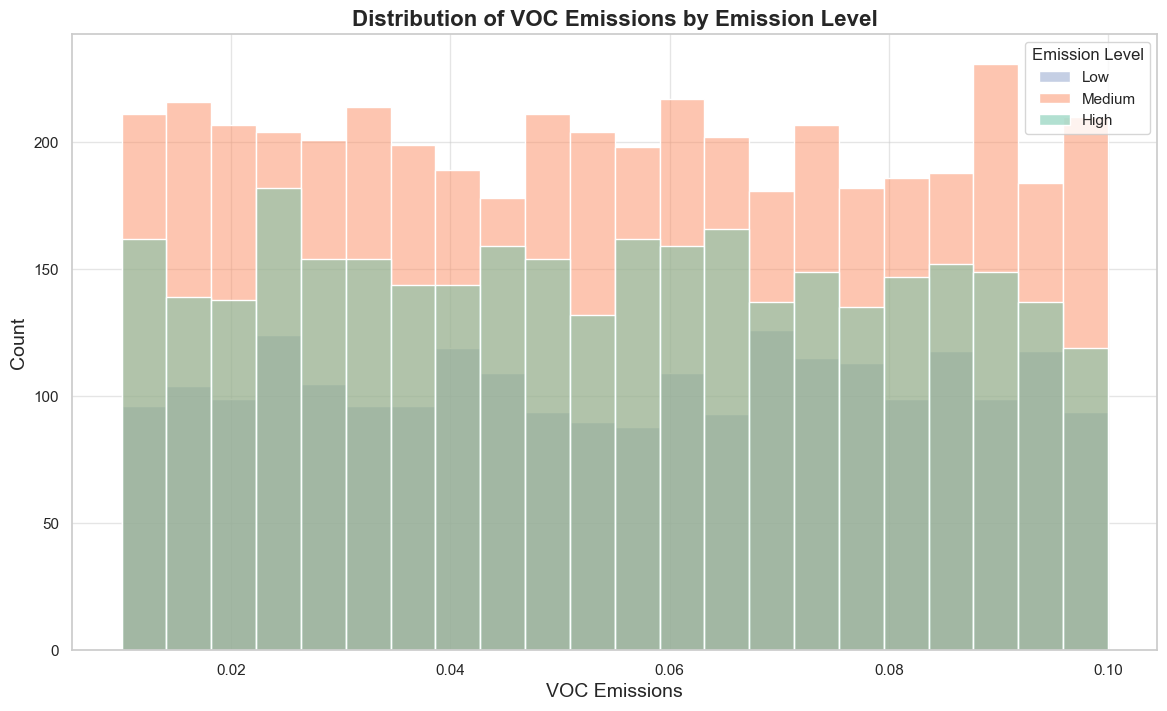

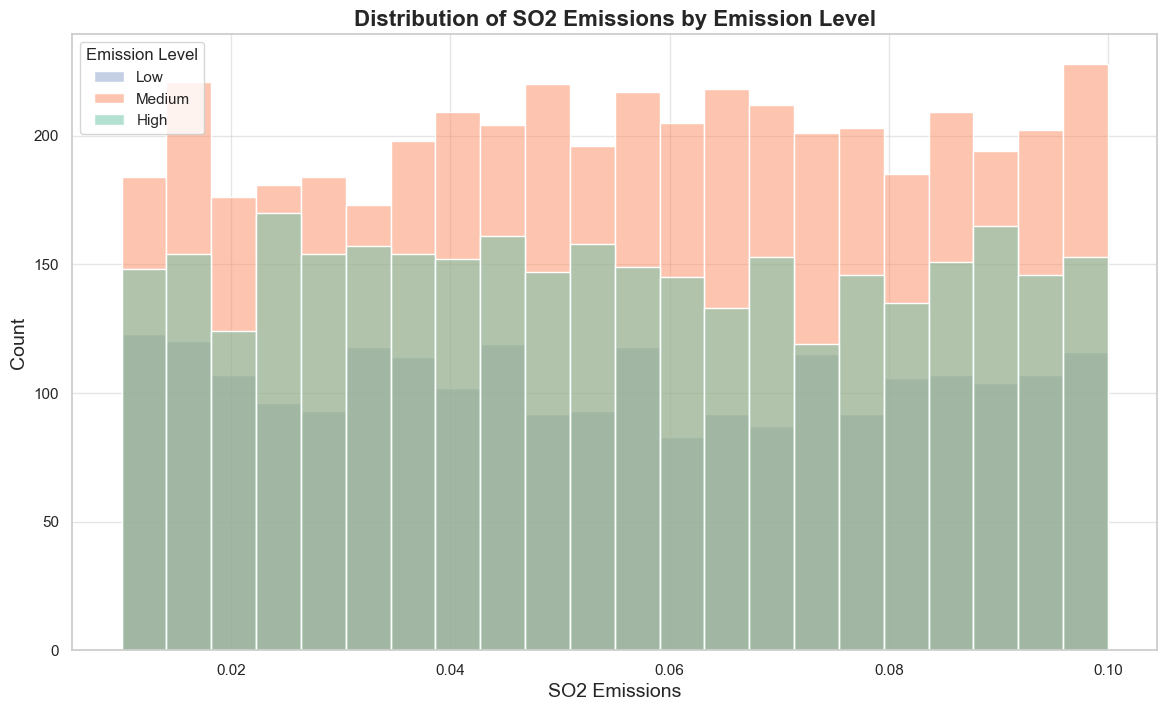

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset (replace with the actual path)
file_path = r'C:\Users\Priyanshu\Desktop\GHG_Model_Project\Dataset\GHG_emissions_dataset_CLEANED.csv'
df = pd.read_csv(file_path)

# Drop irrelevant columns for the analysis (customize as needed)
excluded_columns = ['Region', 'Temperature', 'Rain', 'Ws', 'RH']  # Columns to exclude
dftemp = df.drop(columns=excluded_columns, errors='ignore')  # Exclude columns if they exist

# Loop through each feature in the remaining dataset
for feature in dftemp.columns:
    if feature != 'Emission Level':  # Skip the hue column itself
        plt.figure(figsize=(14, 8))
        sns.histplot(data=dftemp, x=feature, hue='Emission Level', kde=False, palette='Set2')
        plt.legend(title='Emission Level', labels=['Low', 'Medium', 'High'])  # Customize labels as needed
        plt.title(f'Distribution of {feature} by Emission Level', fontsize=16, weight='bold')
        plt.xlabel(feature, fontsize=14)
        plt.ylabel('Count', fontsize=14)
        plt.grid(alpha=0.5)
        plt.show()

In [112]:
import pandas as pd

# Load dataset
file_path = r'C:\Users\Priyanshu\Desktop\GHG_Model_Project\Dataset\GHG_emissions_dataset_CLEANED.csv'
df = pd.read_csv(file_path)

# Example Summary: Weather System Report
def generate_weather_report(df):
    print("### Weather System Report")
    if 'Temperature' in df.columns:
        print("* **Temperature**: Analyze emission levels across temperature ranges.")
    if 'Rain' in df.columns:
        print("* **Rain**: Analyze emission levels for different rainfall levels.")
    if 'Wind Speed' in df.columns:
        print("* **Wind Speed**: Analyze emission levels across wind speed ranges.")
    if 'RH' in df.columns:
        print("* **Relative Humidity (RH)**: Analyze emission levels at different humidity levels.")

# Example Summary: FWI System Components Report
def generate_emission_component_report(df):
    print("\n### FWI System Components Report")
    if 'CO2 Emissions' in df.columns:
        print("* **CO2 Emissions**: Analyze emissions across urban and industrial regions.")
    if 'PM2.5 Emissions' in df.columns:
        print("* **PM2.5 Emissions**: High values indicate industrial activity or limited vegetation.")
    if 'SO2 Emissions' in df.columns:
        print("* **SO2 Emissions**: Peaks near high traffic and fossil fuel usage.")

# Run the report functions
generate_weather_report(df)
generate_emission_component_report(df)

### Weather System Report
* **Temperature**: Analyze emission levels across temperature ranges.
* **Wind Speed**: Analyze emission levels across wind speed ranges.

### FWI System Components Report
* **CO2 Emissions**: Analyze emissions across urban and industrial regions.
* **PM2.5 Emissions**: High values indicate industrial activity or limited vegetation.
* **SO2 Emissions**: Peaks near high traffic and fossil fuel usage.


### Weather System Report
* **Temperature**: Analyze emission levels across temperature ranges.
* **Wind Speed**: Analyze emission levels across wind speed ranges.

### FWI System Components Report
* **CO2 Emissions**: Analyze emissions across urban and industrial regions.
* **PM2.5 Emissions**: High values indicate industrial activity or limited vegetation.
* **SO2 Emissions**: Peaks near high traffic and fossil fuel usage